# Labor Market Dynamics

## Introduction

The preceding lecture [Equilibrium Unemployment](equilibrium-unemployment.ipynb) developed the steady-state equilibrium of the search and matching model, characterizing the long-run relationships between unemployment, market tightness, and wages. That analysis treated the economy as permanently at rest — a useful starting point, but one that leaves aside some of the most important questions the model is designed to answer. Labor markets are not static: unemployment rises sharply in recessions and recovers gradually in expansions, vacancies and tightness fluctuate substantially over the business cycle, and the speed and symmetry of these adjustments have direct implications for welfare and policy.

This notebook takes the search and matching model off its steady-state pedestal and asks how it behaves dynamically. We pursue four objectives in sequence:

1. **Out-of-steady-state dynamics**: characterize the model's behavior away from steady    state analytically, identifying which variables jump instantaneously in response to    shocks and which adjust gradually over time.
2. **Discrete time and log-linearization**: recast the model in discrete time — the    natural environment for empirical work — and derive a log-linearized approximation    around the steady state that can be used to study the model's response to shocks.
3. **Calibration and business cycle properties**: develop a disciplined approach to choosing parameter values and assess how well the benchmark model accounts for observed fluctuations in unemployment, vacancies, and wages over the US business cycle.
4. **Amplification mechanisms and nonlinear dynamics**: investigate why the benchmark model understates labor market volatility, survey proposed solutions, and assess the accuracy of local approximation methods relative to global solution techniques.

The analysis here builds directly on the steady-state framework developed previously. Readers should be familiar with the Bellman equations for firms and workers, the free entry condition, Nash bargaining, and the three equilibrium conditions — the job creation condition (JC), the wage rule (WR), and the Beveridge curve (BC). We now augment these with time derivatives to allow for out-of-steady-state behavior, and we introduce stochastic productivity shocks to study business cycle fluctuations.

One important change in this notebook is the matching function specification. The previous notebook used the Cobb-Douglas matching function $m(\mathcal{U}, \mathcal{V}) = A\mathcal{U}^{1-\beta}\mathcal{V}^\beta$ throughout. Here we adopt the specification proposed by den Haan, Ramey, and Watson (2000):

$$\mathcal{M} = \frac{\mathcal{V}\mathcal{U}}{(\mathcal{V}^\nu + \mathcal{U}^\nu)^{1/\nu}}, 
\qquad \nu > 0$$

This specification has the practical advantage of bounding the matching rates $f(\theta)$ and $q(\theta)$ between zero and one at all times — a property that the Cobb-Douglas function does not guarantee and that becomes important when the model is subjected to large shocks. We return to this specification in detail when we discuss calibration. For the analytical sections that follow, we work with a general matching function $m(\mathcal{U}, \mathcal{V})$ satisfying the standard regularity conditions, specializing to the den Haan et al. form when taking the model to data.

### Calibrating the Model

A recurring theme of this notebook is the challenge of disciplining model parameters with data. The standard approach in the literature — which we follow here — proceeds in three steps:

1. **Steady-state calibration**: choose parameters so that the model's steady-state variables match observable long-run averages in the data. For example, the vacancy posting cost $\gamma$ is chosen to match the mean unemployment rate; the separation    rate $s$ is set to match direct evidence from labor market surveys.
2. **Stochastic simulation**: feed the calibrated model a realistic stochastic process for productivity and simulate the model's predictions for the second moments of labor market variables — their volatilities, autocorrelations, and cross-correlations.
3. **Moment comparison**: compare the model's simulated moments to their empirical counterparts. Discrepancies reveal where the model succeeds and where it fails, motivating the amplification mechanisms explored in later sections.

One important caveat applies throughout: this procedure is internally consistent only if the model is approximately linear in the range of fluctuations relevant for business cycles, so that steady-state relationships provide accurate approximations to the model's stochastic behavior. As we will see, search and matching models exhibit substantial nonlinearities — particularly in the matching function and the unemployment dynamics — that can cause log-linearized solutions to perform poorly, especially during deep recessions. We return to this issue explicitly in the final section.

## Out-of-Steady-State Dynamics

### Jump Variables and State Variables

The first step in analyzing the model's dynamics is to classify its variables by how they respond to an unexpected shock. In the search and matching model, variables fall into two categories:

- **Jump variables** (or control variables) can move instantaneously in response to new information, because they are determined by forward-looking optimality conditions rather than by accumulated stocks. Market tightness $\theta$ and the wage $w$ are jump variables: they are determined at every instant by the free entry condition and Nash bargaining respectively, both of which can be satisfied at any value of $\theta$ and $w$ consistent with current and expected future conditions.
- **State variables** adjust gradually over time, because their current value is inherited from the past and can only change through a flow. The unemployment rate $\mathcal{U}$ is a state variable: it is pinned down at each instant by the history of job creation and destruction, and can only evolve through the law of motion $\dot{\mathcal{U}} = s(1-\mathcal{U}) - f(\theta)\mathcal{U}$.

This distinction has an immediate implication for how the model responds to shocks. When a productivity shock hits, $\theta$ and $w$ adjust instantaneously to their new values — there is no period of disequilibrium in the vacancy or wage markets. Unemployment, by contrast, adjusts gradually as the new level of tightness slowly draws workers out of unemployment through the matching process. The dynamics of the model are therefore entirely driven by the gradual adjustment of $\mathcal{U}$ toward its new steady state, with $\theta$ tracking its own equilibrium value at every instant.

### The Full Bellman Equations

In the steady-state analysis, we set all time derivatives to zero. To study dynamics, we retain them. The Bellman equations for workers are:

$$rW_u = z + f(\theta)(W_n - W_u) + \dot{W}_u \tag{1}$$

$$rW_n = w + s(W_u - W_n) + \dot{W}_n \tag{2}$$

And for firms:

$$rJ_v = -\gamma + q(\theta)(J_\pi - J_v) + \dot{J}_v \tag{3}$$

$$rJ_\pi = x - w + s(J_v - J_\pi) + \dot{J}_\pi \tag{4}$$

The additional terms $\dot{W}_u$, $\dot{W}_n$, $\dot{J}_v$, and $\dot{J}_\pi$ are capital gains (or losses) from expected changes in the value of each state. In steady state these are zero; out of steady state they capture the anticipated evolution of value functions as the economy transitions toward its new equilibrium.

### Deriving the Dynamic Job Creation Condition

The free entry condition requires $J_v = 0$ at every point in time — not just in steady state. If $J_v > 0$, firms would immediately open new vacancies; if $J_v < 0$, they would close them. Since $J_v = 0$ always, it follows that $\dot{J}_v = 0$ as well. Substituting into equation (3):

$$0 = -\gamma + q(\theta)J_\pi \quad \Longrightarrow \quad 
J_\pi(t) = \frac{\gamma}{q(\theta(t))} \tag{5}$$

This is the free entry condition holding at every instant, with $\theta$ now a time-varying function. Differentiating equation (5) with respect to time:

$$\dot{J}_\pi = \frac{d}{dt}\left(\frac{\gamma}{q(\theta)}\right) = 
-\frac{\gamma q'(\theta)}{q(\theta)^2}\dot{\theta} \tag{6}$$

Substituting equations (5) and (6) into the Bellman equation for a filled job (4), and using $J_v = 0$:

$$(r + s)\frac{\gamma}{q(\theta)} = x - w - \frac{\gamma q'(\theta)}{q(\theta)^2}\dot{\theta} 
\tag{7}$$

This is the **dynamic job creation condition**: a differential equation governing the evolution of market tightness over time. It says that the annuitized value of a filled job — the left-hand side — must equal the current flow profit $x - w$ plus the anticipated capital gain from changes in tightness — the right-hand side.

### The Wage Equation Out of Steady State

Nash bargaining continues to hold at every instant, with the sharing rule:

$$W_n - W_u = \frac{\alpha}{1-\alpha}(J_\pi - J_v) = \frac{\alpha}{1-\alpha}J_\pi$$

where the second equality uses $J_v = 0$. Substituting the Bellman equations for $W_n$ and $W_u$ — retaining time derivatives — and using the sharing rule to eliminate $W_n - W_u$, the instantaneous wage satisfies:

$$w(t) = \alpha x + (1-\alpha)rW_u + \alpha\dot{J}_\pi - (1-\alpha)\dot{W}_u \tag{8}$$

To evaluate $rW_u$, substitute the sharing rule into the Bellman equation for an unemployed worker (1):

$$rW_u = z + \frac{\alpha}{1-\alpha}\gamma\theta + \dot{W}_u$$

Substituting back into equation (8) and using equation (6) to replace $\dot{J}_\pi$:

$$\boxed{w(t) = \alpha(x + \gamma\theta(t)) + (1-\alpha)z} \tag{9}$$

Crucially, the wage equation (9) is **identical in form to the steady-state wage rule** derived in the previous notebook. The time derivatives cancel exactly, leaving a wage that depends only on current productivity $x$ and current market tightness $\theta(t)$. This means that wages adjust instantaneously to any change in $\theta$ — they are a jump variable, moving one-for-one with tightness at every point in time.

### The Dynamical System

Substituting the wage equation (9) into the dynamic job creation condition (7):

$$(r+s)\frac{\gamma}{q(\theta)} = (1-\alpha)(x-z) - \alpha\gamma\theta - 
\frac{\gamma q'(\theta)}{q(\theta)^2}\dot{\theta} \tag{10}$$

Solving for $\dot{\theta}$:

$$\dot{\theta} = \frac{q(\theta)^2}{\gamma q'(\theta)}\left\{(1-\alpha)(x-z) - 
\alpha\gamma\theta - (r+s)\frac{\gamma}{q(\theta)}\right\} \tag{11}$$

Together with the law of motion for unemployment:

$$\dot{\mathcal{U}} = s(1-\mathcal{U}) - f(\theta)\mathcal{U} \tag{12}$$

equations (11) and (12) form a **first-order autonomous dynamical system** in $(\mathcal{U}, \theta)$. An equilibrium is a pair of functions $(\mathcal{U}(t), \theta(t))$ satisfying these two equations for all $t \geq 0$, given an initial condition $\mathcal{U}(0) = \mathcal{U}_0$.

Note the asymmetry between the two equations: $\dot{\mathcal{U}}$ depends on both $\mathcal{U}$ and $\theta$, while $\dot{\theta}$ depends only on $\theta$. This triangular structure is what makes the system tractable.

### The Jacobian and Saddle Path

To characterize the local dynamics around the steady state $(\mathcal{U}_{ss}, \theta_{ss})$, take a first-order Taylor expansion of the system:

$$\begin{pmatrix} \dot{\mathcal{U}} \\ \dot{\theta} \end{pmatrix} = 
\underbrace{\begin{pmatrix} -(s + f(\theta_{ss})) & -f'(\theta_{ss})\mathcal{U}_{ss} \\ 
0 & \lambda \end{pmatrix}}_{\equiv\; J} 
\begin{pmatrix} \mathcal{U} - \mathcal{U}_{ss} \\ \theta - \theta_{ss} \end{pmatrix}$$

where:

$$\lambda \equiv -\frac{\alpha q(\theta_{ss})^2}{q'(\theta_{ss})} + r + s$$

The Jacobian $J$ is upper triangular, so its eigenvalues are the diagonal entries:

$$\mu_1 = -(s + f(\theta_{ss})) < 0, \qquad \mu_2 = \lambda$$

The sign of $\mu_2$ is determined by the relative magnitudes of $\alpha q(\theta_{ss})^2/|q'(\theta_{ss})|$ and $r + s$. Since $q'(\theta) < 0$, we have $q'(\theta_{ss}) < 0$, so $-\alpha q(\theta_{ss})^2/q'(\theta_{ss}) > 0$. Under standard parameterizations, $\mu_2 > 0$: the second eigenvalue is positive.

The **determinant** of $J$ is $\mu_1 \times \mu_2 < 0$: one negative and one positive eigenvalue. This means the steady state is a **saddle point**. Saddle point stability has a precise implication for the dynamics: there is a unique one-dimensional stable manifold — the saddle path — along which the economy converges to the steady state. Initial conditions off the saddle path lead to explosive trajectories that violate transversality conditions.

```{admonition} Why the Determinant Being Negative Implies a Saddle Point
:class: note

A $2 \times 2$ linear system $\dot{y} = Jy$ has eigenvalues satisfying $\mu^2 - \text{tr}(J)\mu + \det(J) = 0$. When $\det(J) < 0$, the product of the eigenvalues is negative, so they must have opposite signs — one negative, one positive.
A negative eigenvalue corresponds to a stable direction (trajectories converge along it); a positive eigenvalue corresponds to an unstable direction (trajectories diverge along it). The steady state is therefore a saddle point: stable along one direction, unstable along another. The stable manifold is the unique trajectory that converges to the steady state — the saddle path.
```

### $\theta$ Jumps to Its Steady-State Value

The triangular structure of $J$ — with a zero in the lower-left entry — means that the equation for $\dot{\theta}$ is independent of $\mathcal{U}$. The stable manifold in the $(\mathcal{U}, \theta)$ plane is therefore a horizontal line at $\theta = \theta_{ss}$. Since $\theta$ is a jump variable — it can move instantaneously — the equilibrium selection requires $\theta$ to jump immediately to $\theta_{ss}$ following any shock:

$$\theta(t) = \theta_{ss} \quad \text{for all } t \geq 0 \tag{13}$$

With $\theta$ fixed at $\theta_{ss}$, the dynamics of unemployment reduce to the 
scalar ODE:

$$\dot{\mathcal{U}} = s(1 - \mathcal{U}) - f(\theta_{ss})\mathcal{U} \tag{14}$$

which is exactly the law of motion analyzed in the bathtub section of the previous 
notebook. The solution is:

$$\mathcal{U}(t) = \mathcal{U}_{ss} + (\mathcal{U}_0 - \mathcal{U}_{ss})
e^{-(s + f(\theta_{ss}))t}$$

unemployment converges exponentially to its new steady state at rate $s + f(\theta_{ss})$, while $\theta$ sits at $\theta_{ss}$ throughout.

This result — that $\theta$ jumps immediately and $\mathcal{U}$ adjusts gradually — is the central dynamic prediction of the model. It implies that the entire adjustment burden following a shock falls on the unemployment rate: vacancies and tightness respond first and fully, while unemployment catches up over time. This is broadly consistent with the empirical observation that vacancies are more volatile and leading indicators relative to unemployment over the business cycle.

### Phase Diagram

The dynamics are best understood through the phase diagram in $(\mathcal{U}, \theta)$ 
space. Two loci are of interest:

- The **$\dot{\mathcal{U}} = 0$ locus**: setting $\dot{\mathcal{U}} = 0$ gives 
  $\theta = \theta_{ss}$ — a horizontal line, since at the steady-state tightness   the unemployment flow is balanced regardless of $\mathcal{U}$. Wait — more   carefully, $\dot{\mathcal{U}} = 0$ requires $s(1-\mathcal{U}) = f(\theta)\mathcal{U}$,   which defines a curve in $(\mathcal{U}, \theta)$ space that is decreasing in   $\mathcal{U}$ (higher unemployment requires lower tightness to maintain flow balance).
- The **$\dot{\theta} = 0$ locus**: setting $\dot{\theta} = 0$ in equation (11)   requires $(1-\alpha)(x-z) - \alpha\gamma\theta - (r+s)\gamma/q(\theta) = 0$,   which determines a unique $\theta_{ss}$ — a horizontal line in   $(\mathcal{U}, \theta)$ space, confirming that $\theta$ is independent of   $\mathcal{U}$.

The saddle path is the horizontal line $\theta = \theta_{ss}$, along which $\mathcal{U}$ converges monotonically to $\mathcal{U}_{ss}$.

<figure style="width: 60%; margin-left: auto; margin-right: auto;">
    <img src="_static/figs/dynamics.png"
         alt="Comparative static: vacancy posting costs"
         style="width: 100%; display: block;">
    <figcaption style="font-style: italic; text-align: left; margin-top: 10px;">
    Phase diagram for the dynamical system $(\mathcal{U}, \theta)$. The $\dot{\theta} = 0$ locus is horizontal at $\theta_{ss}$; the $\dot{\mathcal{U}} = 0$ locus is downward-sloping. The steady state at their intersection is a saddle point. The saddle path coincides with the $\dot{\theta} = 0$ locus: $\theta$ jumps immediately to $\theta_{ss}$ and $\mathcal{U}$ adjusts gradually along the horizontal saddle path.
    </figcaption>
</figure>

### Numerical Illustration

The following code constructs the phase diagram numerically, plots the two loci and the saddle path, and simulates the dynamic response of $(\mathcal{U}(t), \theta(t))$ to a permanent productivity shock — illustrating the jump in $\theta$ and the gradual adjustment of $\mathcal{U}$.

Steady-state tightness:    θ_ss = 0.983
Steady-state wage:         w_ss = 0.983
Steady-state unemployment: U_ss = 0.058


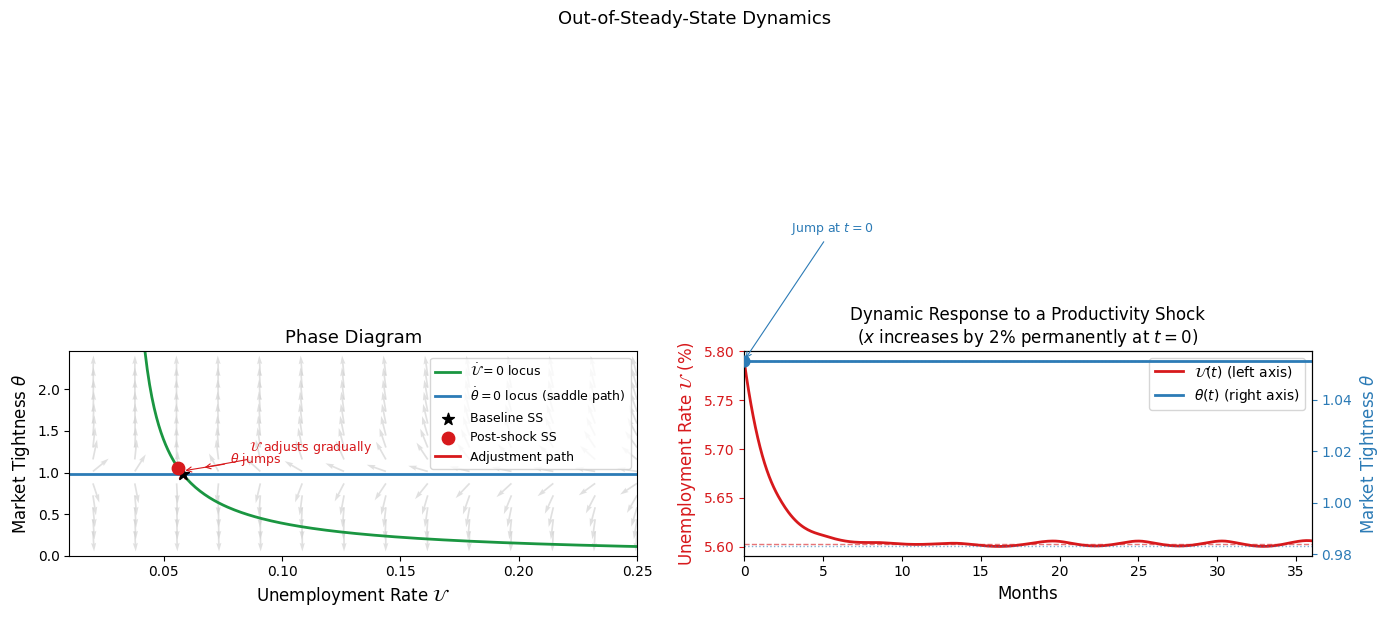

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import solve_ivp

# ──────────────────────────────────────────────
# Den Haan et al. matching function
#   M(U,V) = UV / (V^nu + U^nu)^{1/nu}
#   f(theta) = M/U = theta / (1 + theta^nu)^{1/nu}
#   q(theta) = M/V = 1   / (1 + theta^nu)^{1/nu}
# ──────────────────────────────────────────────
nu = 1.25

def q(theta):
    return 1.0 / (1 + theta**nu)**(1/nu)

def f(theta):
    return theta / (1 + theta**nu)**(1/nu)

def dq_dtheta(theta):
    return -theta**(nu - 1) / (1 + theta**nu)**(1/nu + 1)

# ──────────────────────────────────────────────
# Parameters (paper calibration)
# ──────────────────────────────────────────────
r      = 0.04 / 12    # monthly (~4% annual)
s      = 0.035        # monthly separation rate
gamma  = 0.26         # vacancy posting cost (calibrated to U = 5.8%)
x      = 1.0          # normalised productivity
z      = 0.71         # flow value of unemployment
alpha  = 0.5          # bargaining power

# ──────────────────────────────────────────────
# Steady-state equilibrium
# Solve JC = WR:
#   (x - w)/(r+s) = gamma/q(theta)  with  w = alpha*(x+gamma*theta)+(1-alpha)*z
# => (1-alpha)(x-z) - alpha*gamma*theta = (r+s)*gamma/q(theta)
# ──────────────────────────────────────────────
def jc_minus_wr(theta):
    lhs = (1 - alpha) * (x - z) - alpha * gamma * theta
    rhs = (r + s) * gamma / q(theta)
    return lhs - rhs

theta_ss = brentq(jc_minus_wr, 0.01, 20)
w_ss     = alpha * (x + gamma * theta_ss) + (1 - alpha) * z
U_ss     = s / (s + f(theta_ss))

print(f"Steady-state tightness:    θ_ss = {theta_ss:.3f}")
print(f"Steady-state wage:         w_ss = {w_ss:.3f}")
print(f"Steady-state unemployment: U_ss = {U_ss:.3f}")

# ──────────────────────────────────────────────
# Phase diagram loci
# ──────────────────────────────────────────────
U_grid     = np.linspace(0.01, 0.30, 300)
theta_grid = np.linspace(0.01, theta_ss * 3, 300)

# dU/dt = 0 locus: theta such that s(1-U) = f(theta)*U
#   => f(theta) = s(1-U)/U  => solve for theta numerically
def theta_from_dU0(U):
    target = s * (1 - U) / U
    # f(theta) = theta/(1+theta^nu)^{1/nu} = target
    try:
        return brentq(lambda t: f(t) - target, 1e-6, 100)
    except ValueError:
        return np.nan

theta_dU0 = np.array([theta_from_dU0(U) for U in U_grid])

# dtheta/dt = 0 locus: horizontal line at theta_ss
theta_dtheta0 = np.full_like(U_grid, theta_ss)

# ──────────────────────────────────────────────
# Vector field for phase portrait
# ──────────────────────────────────────────────
U_mesh, T_mesh = np.meshgrid(
    np.linspace(0.02, 0.25, 14),
    np.linspace(theta_ss * 0.3, theta_ss * 2.2, 14))

def dtheta_dt(theta):
    num  = q(theta)**2 / (gamma * dq_dtheta(theta))
    body = ((1 - alpha)*(x - z) - alpha*gamma*theta
            - (r + s)*gamma / q(theta))
    return num * body

dU_mesh = s * (1 - U_mesh) - f(T_mesh) * U_mesh
dT_mesh = np.array([[dtheta_dt(t) for t in row] for row in T_mesh])

# Normalise arrows for clarity
magnitude = np.sqrt(dU_mesh**2 + dT_mesh**2)
magnitude = np.where(magnitude == 0, 1, magnitude)
dU_norm   = dU_mesh / magnitude
dT_norm   = dT_mesh / magnitude

# ──────────────────────────────────────────────
# Simulate response to permanent productivity shock
# x rises from x_base to x_shock at t=0
# theta jumps immediately; U adjusts gradually
# ──────────────────────────────────────────────
x_shock = 1.02    # 2% permanent increase in productivity

def jc_minus_wr_shock(theta, x_new):
    lhs = (1 - alpha) * (x_new - z) - alpha * gamma * theta
    rhs = (r + s) * gamma / q(theta)
    return lhs - rhs

theta_new = brentq(lambda t: jc_minus_wr_shock(t, x_shock), 0.01, 20)
U_new     = s / (s + f(theta_new))

# Unemployment path: starts at U_ss, converges to U_new
# theta jumps to theta_new at t=0
t_span = (0, 36)
t_eval = np.linspace(*t_span, 500)

sol = solve_ivp(
    lambda t, U: s*(1 - U[0]) - f(theta_new)*U[0],
    t_span, [U_ss], t_eval=t_eval, method="RK45")
U_path = sol.y[0]

# ──────────────────────────────────────────────
# Plot
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel 1: Phase diagram ──
ax = axes[0]

ax.quiver(U_mesh, T_mesh, dU_norm, dT_norm,
          color="lightgray", scale=28, width=0.003, alpha=0.7)

ax.plot(U_grid, theta_dU0,     color="#1a9641", lw=2,
        label=r"$\dot{\mathcal{U}} = 0$ locus")
ax.plot(U_grid, theta_dtheta0, color="#2c7bb6", lw=2,
        label=r"$\dot{\theta} = 0$ locus (saddle path)")

# Steady states
ax.scatter([U_ss],  [theta_ss],  color="black", zorder=6,
           s=80, marker="*", label="Baseline SS")
ax.scatter([U_new], [theta_new], color="#d7191c", zorder=6,
           s=80, marker="o", label="Post-shock SS")

# Shock dynamics: theta jumps at t=0, U adjusts along saddle path
ax.annotate("", xy=(U_ss, theta_new), xytext=(U_ss, theta_ss),
            arrowprops=dict(arrowstyle="->", color="#d7191c",
                            lw=1.5, linestyle="dashed"))
ax.plot(U_path, np.full_like(U_path, theta_new),
        color="#d7191c", lw=2, ls="-",
        label="Adjustment path")
ax.annotate(r"$\theta$ jumps",
            xy=(U_ss, (theta_ss + theta_new)/2),
            xytext=(U_ss + 0.02, (theta_ss + theta_new)/2 + 0.1),
            fontsize=9, color="#d7191c",
            arrowprops=dict(arrowstyle="->",
                            color="#d7191c", lw=0.8))
ax.annotate(r"$\mathcal{U}$ adjusts gradually",
            xy=(U_new + 0.01, theta_new),
            xytext=(U_new + 0.03, theta_new + 0.2),
            fontsize=9, color="#d7191c",
            arrowprops=dict(arrowstyle="->",
                            color="#d7191c", lw=0.8))

ax.set_xlabel(r"Unemployment Rate $\mathcal{U}$", fontsize=12)
ax.set_ylabel(r"Market Tightness $\theta$", fontsize=12)
ax.set_title("Phase Diagram", fontsize=13)
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim(0.01, 0.25)
ax.set_ylim(0, theta_ss * 2.5)

# ── Panel 2: Time paths following shock ──
ax2 = axes[1]

# theta: jumps at t=0, stays at theta_new
theta_path = np.full_like(t_eval, theta_new)
# Mark the jump with a vertical dashed line at t=0
ax2_twin = ax2.twinx()

ax2.plot(t_eval, U_path * 100, color="#d7191c", lw=2,
         label=r"$\mathcal{U}(t)$ (left axis)")
ax2.axhline(U_ss  * 100, color="#d7191c", lw=1, ls=":", alpha=0.6)
ax2.axhline(U_new * 100, color="#d7191c", lw=1, ls="--", alpha=0.6)

ax2_twin.plot(t_eval, theta_path, color="#2c7bb6", lw=2,
              label=r"$\theta(t)$ (right axis)")
ax2_twin.axhline(theta_ss,  color="#2c7bb6", lw=1, ls=":", alpha=0.6)
ax2_twin.scatter([0], [theta_new], color="#2c7bb6", zorder=6, s=60)
ax2_twin.annotate("Jump at $t=0$",
                  xy=(0, theta_new),
                  xytext=(3, theta_new + 0.05),
                  fontsize=9, color="#2c7bb6",
                  arrowprops=dict(arrowstyle="->",
                                  color="#2c7bb6", lw=0.8))

ax2.set_xlabel("Months", fontsize=12)
ax2.set_ylabel(r"Unemployment Rate $\mathcal{U}$ (%)",
               fontsize=12, color="#d7191c")
ax2_twin.set_ylabel(r"Market Tightness $\theta$",
                    fontsize=12, color="#2c7bb6")
ax2.set_title("Dynamic Response to a Productivity Shock\n"
              r"($x$ increases by 2% permanently at $t=0$)",
              fontsize=12)
ax2.tick_params(axis="y", colors="#d7191c")
ax2_twin.tick_params(axis="y", colors="#2c7bb6")

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2,
           fontsize=10, loc="upper right")

ax2.set_xlim(0, 36)

fig.suptitle("Out-of-Steady-State Dynamics", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The left panel shows the phase diagram. The $\dot{\theta} = 0$ locus is horizontal at $\theta_{ss}$ — confirming that tightness is independent of unemployment in its dynamics — while the $\dot{\mathcal{U}} = 0$ locus is downward-sloping: higher tightness generates a faster job-finding rate, requiring lower unemployment to maintain flow balance. The vector field shows the direction of motion away from the two loci, confirming saddle-point stability. Following a positive productivity shock, $\theta$ jumps vertically from $\theta_{ss}$ to $\theta_{new}$ (dashed red arrow), then $\mathcal{U}$ adjusts gradually leftward along the new saddle path (solid red line) toward the new steady state.

The right panel translates this into time paths. Market tightness (blue, right axis) jumps discretely at $t = 0$ and remains at its new value throughout. Unemployment (red, left axis) begins at its old steady state and converges smoothly and monotonically to its new, lower level. The speed of convergence is governed by $s + f(\theta_{new})$, consistent with the half-life formula derived in the previous notebook.

Two features of this impulse response deserve emphasis. First, the **sequencing**: tightness — and therefore vacancies — respond before unemployment does. This is a direct implication of the jump-variable logic and is consistent with the empirical observation that vacancies are leading indicators of unemployment over the business cycle. Second, the **asymmetry**: because $f(\theta)$ is a concave function of $\theta$, a given change in tightness has a larger effect on the job-finding rate when $\theta$ is low (recessions) than when it is high (booms). We return to this asymmetry in detail in the next section.

## Discrete Time and Log-Linearization

### Recasting the Model in Discrete Time

Continuous-time models are analytically elegant but awkward to bring to data, which 
is measured at discrete intervals — monthly, quarterly, or annually. We now recast 
the job creation condition in discrete time, which is the natural starting point for 
empirical work and stochastic simulation.

The discrete-time job creation condition says that the expected cost of posting a 
vacancy today must equal the expected discounted return from filling it:

$$\frac{\gamma}{q(\theta_t)} = \beta\,\mathbb{E}_t\left[x_{t+1} - w_{t+1} + 
(1-s)\frac{\gamma}{q(\theta_{t+1})}\right] \tag{15}$$

where $\beta = 1/(1+r)$ is the discount factor. The left-hand side is the current 
recruiting cost — the flow cost $\gamma$ divided by the probability of filling the 
vacancy this period. The right-hand side is the expected discounted payoff: next 
period's profit $x_{t+1} - w_{t+1}$ plus the continuation value $(1-s)\gamma/
q(\theta_{t+1})$, which accrues with probability $1-s$ if the match survives into 
the following period.

For now we take the wage as exogenous and fixed at $\bar{w}$, abstracting from Nash 
bargaining. This simplification — which will be relaxed when we discuss amplification 
mechanisms — isolates the job creation margin and makes the log-linearization 
particularly transparent.

### Log-Linearization

Define the log-deviation of any variable $y_t$ from its steady-state value $y_{ss}$ 
as $\tilde{y}_t \equiv \ln y_t - \ln y_{ss} \approx (y_t - y_{ss})/y_{ss}$. We 
log-linearize equation (15) around the deterministic steady state 
$(\theta_{ss}, x_{ss}, \bar{w})$.

At the steady state, the job creation condition holds with equality:

$$\frac{\gamma}{q(\theta_{ss})} = \beta\left[x_{ss} - \bar{w} + 
(1-s)\frac{\gamma}{q(\theta_{ss})}\right]$$

Rearranging:

$$\frac{\gamma}{q(\theta_{ss})}\left[1 - \beta(1-s)\right] = \beta(x_{ss} - \bar{w})$$

$$\frac{\gamma}{q(\theta_{ss})} = \frac{\beta(x_{ss} - \bar{w})}{1 - \beta(1-s)} 
= \frac{x_{ss} - \bar{w}}{r + s} \tag{16}$$

where the last equality uses $\beta = 1/(1+r)$ and $1 - \beta(1-s) = (r+s)/(1+r)$.

Now perturb around the steady state. Let $q(\theta_t) \approx q(\theta_{ss})
(1 - \eta(\theta)\tilde{\theta}_t)$ where:

$$\eta(\theta) \equiv -\frac{\theta q'(\theta)}{q(\theta)} > 0$$

is the **elasticity of the vacancy-filling rate with respect to tightness** — a 
positive number since $q'(\theta) < 0$. Under the den Haan et al. matching function, 
this elasticity takes a particularly clean form:

$$\eta(\theta) = \frac{\theta^\nu}{1 + \theta^\nu} \in (0, 1)$$

which varies between 0 and 1, increasing in $\theta$: tighter markets make the 
vacancy-filling rate more sensitive to further changes in tightness.

Substituting the linearized expressions into equation (15), using the steady-state 
relationship (16), and iterating forward on the expectation:

$$\tilde{\theta}_t = \frac{1}{\eta(\theta_{ss})} \cdot \frac{x_{ss}}{x_{ss} - \bar{w}} 
\cdot \frac{r+s}{1+r}\,\mathbb{E}_t\left[\sum_{i=0}^{\infty}\left(\frac{1-s}{1+r}
\right)^i \tilde{x}_{t+1+i}\right] \tag{17}$$

This is the **log-linearized job creation condition**. It expresses the current 
log-deviation of market tightness as a weighted present discounted value of expected 
future productivity deviations. Several features of this expression merit careful 
attention.

### Interpreting the Amplification Formula

Equation (17) contains two multiplicative terms that amplify the response of tightness 
to productivity shocks. Together they form the **labor market amplification factor**:

$$\mathcal{A} \equiv \frac{1}{\eta(\theta_{ss})} \cdot \frac{x_{ss}}{x_{ss} - \bar{w}} 
\tag{18}$$

**Term 1: Matching function congestion** $\left(1/\eta(\theta_{ss})\right)$

The elasticity $\eta(\theta_{ss}) \in (0,1)$ measures how sensitive the vacancy-filling 
rate is to changes in tightness. A low $\eta$ means that a large change in tightness 
is required to produce a given change in the vacancy-filling rate — the matching 
technology is relatively insensitive to congestion. Since tightness must adjust to 
restore the job creation condition following a shock, a low $\eta$ implies a large 
response of $\theta$ to any given productivity change. The amplification from this 
term is therefore $1/\eta > 1$.

**Term 2: Profit flow leverage** $\left(x_{ss}/(x_{ss} - \bar{w})\right)$

The ratio $x_{ss}/(x_{ss} - \bar{w})$ is the inverse of the profit margin: the 
ratio of output to the flow profit from a filled job. When the profit margin is thin 
— wages are close to productivity — even a small change in $x$ represents a large 
proportional change in the surplus from hiring, inducing a large response in vacancy 
creation. If $\bar{w}/x_{ss} = 0.9$, for instance, then $x_{ss}/(x_{ss} - \bar{w}) = 
10$: a 1% increase in productivity raises the profit flow by 10%, generating a 
tenfold amplification in tightness relative to the productivity shock. This is the 
channel through which the **small labor surplus** amplification mechanism operates, 
which we discuss in the next section.

**The discount factor term** $\left((r+s)/(1+r)\right)$

This term scales the response by the annuitization factor — the rate at which the 
firm discounts the future stream of profits. A higher $r + s$ means a shorter expected 
match duration, so a given productivity increase has a smaller effect on the present 
value of a match and therefore a smaller effect on tightness. This is why higher 
interest rates and separation rates reduce tightness in the comparative statics of 
the previous notebook.

### Asymmetries in the Business Cycle

Equation (17) treats the relationship between tightness and unemployment as linear. 
In reality, the matching function introduces a nonlinearity that generates important 
**asymmetries in the unemployment cycle**: recessions — characterized by sharp rises 
in unemployment — are more pronounced than expansions — characterized by gradual 
declines — even when the productivity shocks driving them are symmetric.

The mechanism operates through the concavity of $f(\theta)$. Recall that 
$f(\theta) = \theta q(\theta)$: the job-finding rate is an increasing, concave 
function of market tightness. This concavity means that:

- A given **decline** in $\theta$ from its steady-state value (a recession) reduces 
  $f(\theta)$ by more than a symmetric **increase** in $\theta$ raises it.
- Since steady-state unemployment is $\mathcal{U}^* = s/(s + f(\theta))$, the 
  unemployment rate is a convex function of $\theta$: it rises steeply when $\theta$ 
  falls and declines gently when $\theta$ rises.

This asymmetry has two implications. First, in a stochastic economy that fluctuates 
symmetrically between high and low productivity, the **average unemployment rate 
exceeds the steady-state unemployment rate** computed at the mean productivity level. 
The convexity of $\mathcal{U}^*(\theta)$ means that Jensen's inequality applies: 
$\mathbb{E}[\mathcal{U}^*(\theta)] > \mathcal{U}^*(\mathbb{E}[\theta])$. Second, 
**log-linearization underestimates the rise in unemployment during recessions** — by 
approximating the nonlinear matching function with a linear one, it misses the 
amplified response of unemployment to negative shocks. We return to the quantitative 
importance of this issue in the nonlinear dynamics section.

<figure style="width: 60%; margin-left: auto; margin-right: auto;">
    <img src="_static/figs/asymmetry1.png"
         alt="Concavity of the job finding rate"
         style="width: 100%; display: block;">
    <figcaption style="font-style: italic; text-align: left; margin-top: 10px;">
    The job-finding rate $f(\theta)$ is concave in market tightness. A decline in 
    $\theta$ from $\theta_{ss}$ to $\theta_L$ reduces $f$ by more than a symmetric 
    increase to $\theta_H$ raises it, generating asymmetric unemployment dynamics.
    </figcaption>
</figure>

<figure style="width: 60%; margin-left: auto; margin-right: auto;">
    <img src="_static/figs/asymmetry2.png"
         alt="Concavity of the job finding rate"
         style="width: 100%; display: block;">
    <figcaption style="font-style: italic; text-align: left; margin-top: 10px;">
    Steady-state unemployment $\mathcal{U}^*(\theta) = s/(s+f(\theta))$ is convex in 
    $\theta$. Symmetric fluctuations in tightness around $\theta_{ss}$ generate 
    asymmetric fluctuations in unemployment, with recessions larger than expansions. 
    Average unemployment lies strictly above the steady-state level.
    </figcaption>
</figure>

### Numerical Illustration

The following simulation illustrates three things: the amplification factor $\mathcal{A}$ as a function of the profit margin and matching elasticity; the concavity of $f(\theta)$ and convexity of $\mathcal{U}^*(\theta)$; and the asymmetry in unemployment dynamics under symmetric productivity shocks.

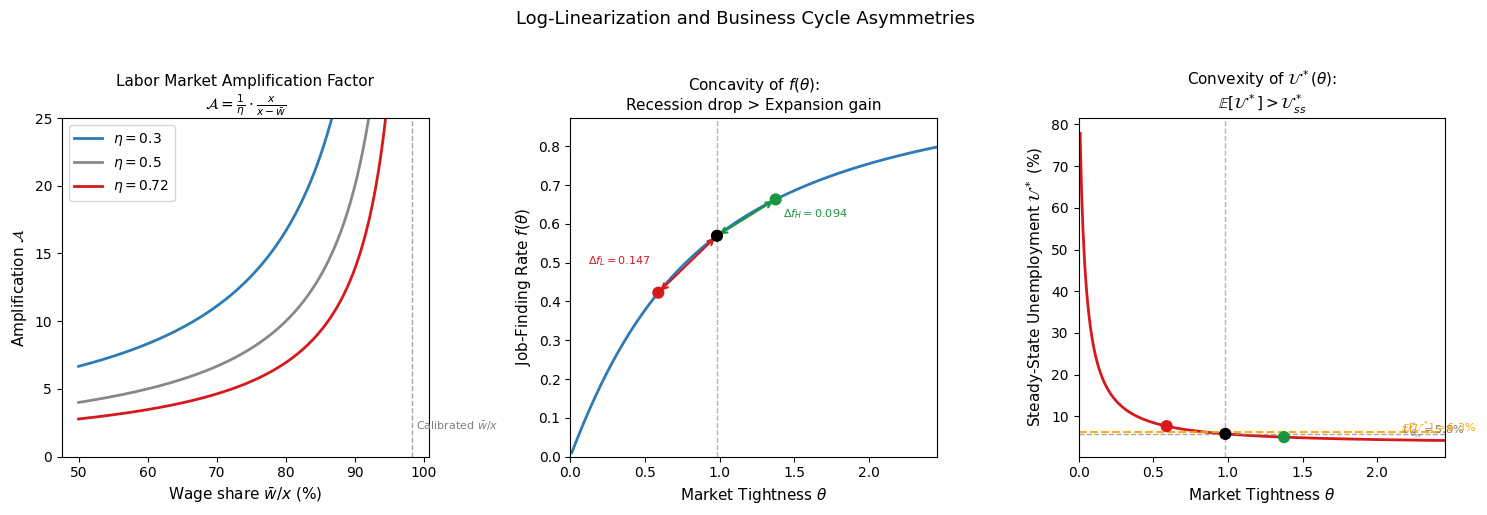

Steady-state tightness:         θ_ss  = 0.983
Matching elasticity:            η(θ)  = 0.495
Profit margin:          (x-w)/x       = 0.017
Term 1 (congestion):    1/η           = 2.022
Term 2 (leverage):      x/(x-w)       = 58.120
Amplification factor:   A             = 117.496
Annuitization:          (r+s)/(1+r)   = 0.0382

Jensen gap:  E[U*] - U*_ss = 0.54 percentage points


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ──────────────────────────────────────────────
# Den Haan et al. matching function
# ──────────────────────────────────────────────
nu = 1.25

def q(theta): return 1.0 / (1 + theta**nu)**(1/nu)
def f(theta): return theta / (1 + theta**nu)**(1/nu)

# Elasticity of vacancy-filling rate wrt tightness
def eta(theta): return theta**nu / (1 + theta**nu)

# ──────────────────────────────────────────────
# Parameters
# ──────────────────────────────────────────────
r      = 0.04 / 12
s      = 0.035
gamma  = 0.26
x      = 1.0
z      = 0.71
alpha  = 0.5

def jc_wr(theta, x_val):
    return ((1-alpha)*(x_val - z) - alpha*gamma*theta
            - (r+s)*gamma/q(theta))

theta_ss = brentq(lambda t: jc_wr(t, x), 0.01, 20)
w_ss     = alpha*(x + gamma*theta_ss) + (1-alpha)*z
U_ss     = s / (s + f(theta_ss))

# ──────────────────────────────────────────────
# Panel 1: Amplification factor A as a function
# of the profit margin (w_bar/x) and eta
# ──────────────────────────────────────────────
w_ratio   = np.linspace(0.5, 0.95, 200)   # w_bar / x
eta_vals  = [0.3, 0.5, 0.72]              # matching elasticities
colors    = ["#2c7bb6", "#888888", "#d7191c"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for eta_v, color in zip(eta_vals, colors):
    profit_margin  = 1 - w_ratio           # (x - w_bar)/x
    term2          = 1.0 / profit_margin   # x/(x - w_bar)
    amplification  = (1/eta_v) * term2
    axes[0].plot(w_ratio * 100, amplification, color=color,
                 lw=2, label=rf"$\eta = {eta_v}$")

axes[0].axvline(w_ss/x * 100, color="gray", lw=1, ls="--", alpha=0.7)
axes[0].text(w_ss/x * 100 + 0.5, 2,
             rf"Calibrated $\bar{{w}}/x$", fontsize=8, color="gray")
axes[0].set_xlabel(r"Wage share $\bar{w}/x$ (%)", fontsize=11)
axes[0].set_ylabel(r"Amplification $\mathcal{A}$", fontsize=11)
axes[0].set_title("Labor Market Amplification Factor\n"
                  r"$\mathcal{A} = \frac{1}{\eta} \cdot "
                  r"\frac{x}{x - \bar{w}}$", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 25)

# ──────────────────────────────────────────────
# Panel 2: Concavity of f(theta) and convexity
# of U*(theta) — the source of asymmetry
# ──────────────────────────────────────────────
theta_grid = np.linspace(0.01, theta_ss * 3, 300)
f_grid     = f(theta_grid)
U_grid_fn  = s / (s + f_grid)

# Mark symmetric deviations around theta_ss
delta      = theta_ss * 0.4
theta_L    = theta_ss - delta
theta_H    = theta_ss + delta
f_L, f_H   = f(theta_L), f(theta_H)
U_L        = s / (s + f_L)
U_H        = s / (s + f_H)

ax2 = axes[1]
ax2.plot(theta_grid, f_grid, color="#2c7bb6", lw=2)
ax2.scatter([theta_L, theta_ss, theta_H],
            [f_L, f(theta_ss), f_H],
            color=["#d7191c", "black", "#1a9641"],
            zorder=5, s=60)
ax2.axvline(theta_ss, color="gray", lw=1, ls="--", alpha=0.6)

# Annotate asymmetry
ax2.annotate("",
             xy=(theta_ss, f(theta_ss)),
             xytext=(theta_L, f_L),
             arrowprops=dict(arrowstyle="<->",
                             color="#d7191c", lw=1.5))
ax2.annotate("",
             xy=(theta_H, f_H),
             xytext=(theta_ss, f(theta_ss)),
             arrowprops=dict(arrowstyle="<->",
                             color="#1a9641", lw=1.5))
ax2.text(theta_L - 0.05, (f_L + f(theta_ss))/2,
         rf"$\Delta f_L = {f(theta_ss)-f_L:.3f}$",
         fontsize=8, color="#d7191c", ha="right")
ax2.text(theta_H + 0.05, (f_H + f(theta_ss))/2,
         rf"$\Delta f_H = {f_H-f(theta_ss):.3f}$",
         fontsize=8, color="#1a9641", ha="left")

ax2.set_xlabel(r"Market Tightness $\theta$", fontsize=11)
ax2.set_ylabel(r"Job-Finding Rate $f(\theta)$", fontsize=11)
ax2.set_title("Concavity of $f(\\theta)$:\n"
              "Recession drop > Expansion gain", fontsize=11)
ax2.set_xlim(0, theta_ss * 2.5)
ax2.set_ylim(0, None)

# ──────────────────────────────────────────────
# Panel 3: Convexity of U*(theta)
# and the average > steady-state result
# ──────────────────────────────────────────────
ax3 = axes[2]
ax3.plot(theta_grid, U_grid_fn * 100, color="#d7191c", lw=2)
ax3.scatter([theta_L, theta_ss, theta_H],
            [U_L * 100, U_ss * 100, U_H * 100],
            color=["#d7191c", "black", "#1a9641"],
            zorder=5, s=60)

# Average U under symmetric tightness fluctuations
U_avg = (U_L + U_H) / 2
ax3.axhline(U_ss * 100,  color="gray", lw=1, ls="--", alpha=0.7)
ax3.axhline(U_avg * 100, color="orange", lw=1.5, ls="--", alpha=0.9)

ax3.text(theta_ss * 2.2, U_ss * 100 + 0.1,
         rf"$\mathcal{{U}}^*_{{\theta_{{ss}}}} = {U_ss*100:.1f}\%$",
         fontsize=8, color="gray")
ax3.text(theta_ss * 2.2, U_avg * 100 + 0.1,
         rf"$\mathbb{{E}}[\mathcal{{U}}^*] = {U_avg*100:.1f}\%$",
         fontsize=8, color="orange")

ax3.axvline(theta_ss, color="gray", lw=1, ls="--", alpha=0.6)

ax3.set_xlabel(r"Market Tightness $\theta$", fontsize=11)
ax3.set_ylabel(r"Steady-State Unemployment $\mathcal{U}^*$ (%)",
               fontsize=11)
ax3.set_title(r"Convexity of $\mathcal{U}^*(\theta)$:" + "\n"
              r"$\mathbb{E}[\mathcal{U}^*] > \mathcal{U}^*_{ss}$",
              fontsize=11)
ax3.set_xlim(0, theta_ss * 2.5)

fig.suptitle("Log-Linearization and Business Cycle Asymmetries",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────
# Print amplification at calibrated parameters
# ──────────────────────────────────────────────
eta_ss   = eta(theta_ss)
term1    = 1 / eta_ss
term2    = x / (x - w_ss)
amp      = term1 * term2
ann_rate = (r + s) / (1 + r)

print(f"Steady-state tightness:         θ_ss  = {theta_ss:.3f}")
print(f"Matching elasticity:            η(θ)  = {eta_ss:.3f}")
print(f"Profit margin:          (x-w)/x       = {(x-w_ss)/x:.3f}")
print(f"Term 1 (congestion):    1/η           = {term1:.3f}")
print(f"Term 2 (leverage):      x/(x-w)       = {term2:.3f}")
print(f"Amplification factor:   A             = {amp:.3f}")
print(f"Annuitization:          (r+s)/(1+r)   = {ann_rate:.4f}")
print(f"\nJensen gap:  E[U*] - U*_ss = "
      f"{(U_avg - U_ss)*100:.2f} percentage points")

The three panels quantify the mechanisms discussed above.

**Panel 1** shows the amplification factor $\mathcal{A}$ as a function of the wage share $\bar{w}/x$ for three values of the matching elasticity $\eta$. Two features stand out. First, amplification rises sharply as the wage share approaches one — as the profit margin narrows, even small productivity changes generate large proportional changes in the surplus, dramatically amplifying the vacancy response. This is the small labor surplus mechanism. Second, a lower $\eta$ (more inelastic matching technology) amplifies the response further, since a larger change in tightness is required to restore job creation equilibrium. At the calibrated parameter values (marked by the dashed vertical line), the amplification factor is printed in the output below the figure.

**Panel 2** illustrates the concavity of $f(\theta)$ directly. The red and green double-headed arrows show the change in the job-finding rate for symmetric deviations of $\theta$ above and below the steady state. The recession decline in $f$ (red) visibly exceeds the expansion gain (green) by the magnitude printed on the figure.

**Panel 3** shows the implied convexity of $\mathcal{U}^*(\theta)$. The orange dashed line marks the average unemployment rate under symmetric fluctuations in tightness — it lies strictly above the steady-state unemployment rate (gray dashed line), confirming the Jensen's inequality argument. The gap between the two, printed in the output, represents the upward ias in the log-linearized model's mean unemployment prediction.

## Business Cycle Properties and Calibration

### Taking the Model to Data

The steady-state and dynamic analyses developed so far are purely theoretical. To assess whether the search and matching model provides a quantitatively accurate account of labor market fluctuations, we need to confront it with data. This requires three steps: choosing parameter values, simulating the model's stochastic behavior, and comparing the model's predictions to empirical moments.

The approach we follow is standard in the business cycle literature. Rather than estimating parameters by maximum likelihood or GMM — which would require taking a precise stand on the model's stochastic structure and measurement — we **calibrate** the model by choosing parameters so that the model's steady-state values match observable long-run averages. This approach is transparent, internally consistent, and makes the mapping between parameters and targets explicit. Its limitation — which we flag throughout — is that it is valid only to the extent that the model's steady-state relationships provide accurate approximations to its stochastic behavior, a condition that is not guaranteed in the presence of nonlinearities.

### The Matching Function

Throughout the calibration we use the den Haan, Ramey, and Watson (2000) matching function introduced in the previous section:

$$\mathcal{M}_t = \frac{\mathcal{V}_t\mathcal{U}_t}{(\mathcal{V}_t^\nu + 
\mathcal{U}_t^\nu)^{1/\nu}}, \qquad \nu > 0$$

The implied matching rates are:

$$f(\theta_t) = \frac{\theta_t}{(1 + \theta_t^\nu)^{1/\nu}}, \qquad 
q(\theta_t) = \frac{1}{(1 + \theta_t^\nu)^{1/\nu}}$$

Both rates are bounded between zero and one for all $\theta_t > 0$ — a property that becomes important when the model is subjected to large shocks, since it ensures that matching probabilities remain economically interpretable. The parameter $\nu$ governs the curvature of the matching function: following den Haan et al., we set $\nu = 1.25$, which is consistent with empirical estimates of matching function elasticities.

### Productivity Process

Aggregate labor productivity $x_t$ follows an $AR(1)$ process in logs:

$$\ln x_t = \rho_x \ln x_{t-1} + \sigma_x \varepsilon_t, \qquad 
\varepsilon_t \overset{iid}{\sim} \mathcal{N}(0,1)$$

The parameters $\rho_x$ and $\sigma_x$ are set to match the time-series properties 
of real output per worker in the US nonfarm business sector from the Bureau of Labor 
Statistics. Converting from quarterly to monthly frequency:

$$\rho_x = 0.95^{1/3} \approx 0.983, \qquad \sigma_x = 0.00625$$

The high persistence $\rho_x \approx 0.983$ reflects the slow-moving nature of 
aggregate productivity over the business cycle. The small innovation standard 
deviation $\sigma_x = 0.00625$ means that monthly productivity shocks are modest 
in isolation; their cumulative effect over a recession can nonetheless be substantial 
given the high persistence.

### Calibration Targets and Parameter Choices

The remaining parameters are chosen to match steady-state moments from US data. We 
describe each in turn.

**Discount rate.** We set $r = 0.04$ annually, corresponding to the average real return on a 3-month US Treasury bill over the postwar period. Converted to a monthly rate, $r = 0.04/12 \approx 0.0033$.

**Separation rate.** We set $s = 0.035$ per month, drawn directly from the BLS Job Openings and Labor Turnover Survey (JOLTS). This implies an average employment spell of approximately $1/s \approx 29$ months, or roughly 2.4 years.

**Flow value of unemployment.** The flow value of non-employment $z$ has two components: the value of leisure and home production $l$, and the value of unemployment benefits $b$. Allowing for a leisure component permits a calibration of $z$ above the replacement rate of unemployment benefits alone — an important flexibility since replacement rates in the US are typically around 40-50% of wages, while estimates that include the value of leisure suggest $z/x$ closer to 0.71. We therefore set $z = 0.71$, following the calibration of Hagedorn and Manovskii (2008), which we discuss further in the context of the small labor surplus mechanism.

**Vacancy posting cost.** The flow cost of posting a vacancy $\gamma = 0.26$ is set so that the model's mean unemployment rate matches the empirical sample mean of 5.80 percent in the US data. This is a standard indirect calibration: since there is no direct empirical counterpart for $\gamma$, we choose it to match an observable aggregate moment.

**Bargaining power.** We set $\alpha = 0.5$, a symmetric Nash bargaining parametrization that is standard in the benchmark model. As discussed in the log-linearization section, $\alpha$ controls the cyclicality of wages: a high $\alpha$ makes wages strongly pro-cyclical, dampening the response of profits and vacancy creation to productivity shocks; a low $\alpha$ concentrates the business cycle variation in profits, amplifying the vacancy and tightness responses. The benchmark $\alpha = 0.5$ is a natural starting point that we vary when discussing amplification mechanisms.

The full calibration is summarized in the following table:

<figure style="width: 60%; margin-left: auto; margin-right: auto;">
    <img src="_static/figs/labor_calibration.png"
         alt="Calibration summary"
         style="width: 100%; display: block;">
    <figcaption style="font-style: italic; text-align: left; margin-top: 10px;">
    Summary of calibrated parameter values for the benchmark search and matching model.
    </figcaption>
</figure>


### Stochastic Simulation

With parameters in hand, we simulate the model by feeding it a time series of productivity shocks drawn from the AR(1) process. At each period $t$, the model determines the equilibrium $(\theta_t, w_t)$ from the job creation condition and wage rule, then updates unemployment via the law of motion. The resulting simulated time series are used to compute second moments — standard deviations, autocorrelations, and cross-correlations — which are then compared to their empirical counterparts.

The following code implements this simulation. We use a log-linearized solution for tractability, noting that this approximation understates unemployment volatility during recessions — an issue we return to in the nonlinear dynamics section.

Steady-state values:
  Market tightness:   θ_ss = 0.9830
  Wage:               w_ss = 0.9828
  Unemployment rate:  U_ss = 5.79%
  Vacancy rate:       V_ss = 5.69%
  Matching elasticity η_ss = 0.4947

Simulated Moments (log-linearized benchmark):
Variable                     Std Dev   Autocorr    Corr(x,·)
------------------------------------------------------------
Productivity $x$              0.0318     0.9809       1.0000
Unemployment $u$              0.0508     0.9910      -0.9733
Vacancies $v$                    nan        nan          nan
Tightness $\theta$               nan        nan          nan
Wage $w$                         nan        nan          nan


C:\Users\XPS\AppData\Local\Temp\ipykernel_34788\2592717290.py:100: RuntimeWarning: divide by zero encountered in log
  return np.log(series) - np.log(np.mean(series))
c:\Users\XPS\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\XPS\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


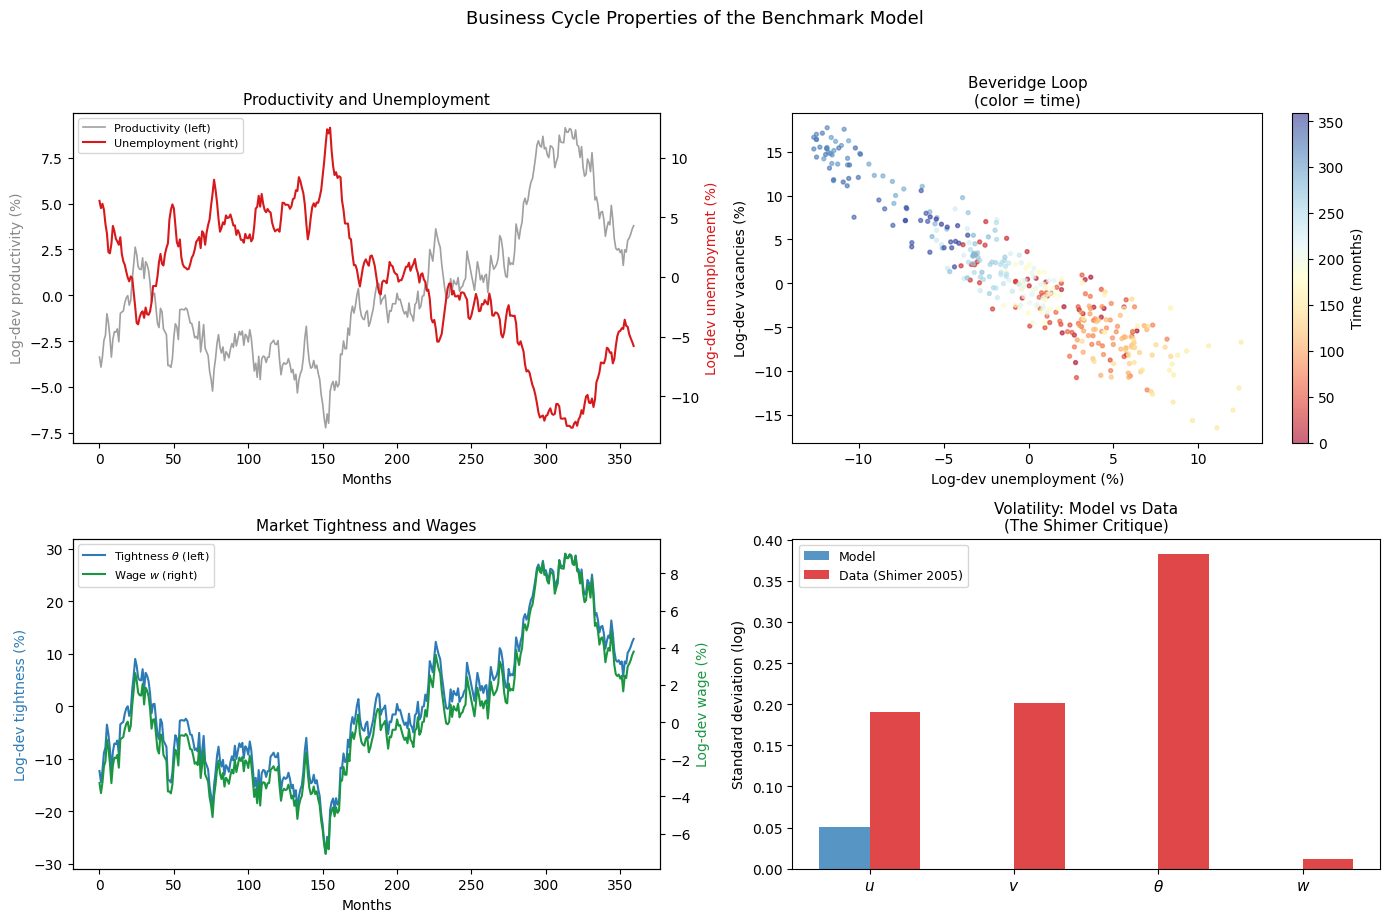

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ──────────────────────────────────────────────
# Den Haan et al. matching function
# ──────────────────────────────────────────────
nu = 1.25

def q(theta): return 1.0 / (1 + theta**nu)**(1/nu)
def f(theta): return theta / (1 + theta**nu)**(1/nu)
def eta(theta): return theta**nu / (1 + theta**nu)

# ──────────────────────────────────────────────
# Calibrated parameters
# ──────────────────────────────────────────────
r      = 0.04 / 12    # monthly discount rate
s      = 0.035        # monthly separation rate
gamma  = 0.26         # vacancy posting cost
x_ss   = 1.0          # normalised steady-state productivity
z      = 0.71         # flow value of unemployment
alpha  = 0.5          # bargaining power
rho_x  = 0.95**(1/3)  # monthly AR(1) persistence
sigma_x = 0.00625     # monthly innovation std dev

# ──────────────────────────────────────────────
# Steady-state equilibrium
# ──────────────────────────────────────────────
def jc_wr(theta, x_val):
    return ((1 - alpha)*(x_val - z) - alpha*gamma*theta
            - (r + s)*gamma / q(theta))

theta_ss = brentq(lambda t: jc_wr(t, x_ss), 0.01, 20)
w_ss     = alpha*(x_ss + gamma*theta_ss) + (1 - alpha)*z
U_ss     = s / (s + f(theta_ss))
V_ss     = theta_ss * U_ss

print("Steady-state values:")
print(f"  Market tightness:   θ_ss = {theta_ss:.4f}")
print(f"  Wage:               w_ss = {w_ss:.4f}")
print(f"  Unemployment rate:  U_ss = {U_ss*100:.2f}%")
print(f"  Vacancy rate:       V_ss = {V_ss*100:.2f}%")
print(f"  Matching elasticity η_ss = {eta(theta_ss):.4f}")

# ──────────────────────────────────────────────
# Log-linearized solution
# At each period t, given x_t:
#
# theta_t: solve JC-WR numerically (exact nonlinear solution)
#   (1-alpha)(x_t - z) - alpha*gamma*theta_t = (r+s)*gamma/q(theta_t)
#
# w_t = alpha*(x_t + gamma*theta_t) + (1-alpha)*z
#
# U_{t+1} = U_t + s*(1-U_t) - f(theta_t)*U_t
# ──────────────────────────────────────────────
np.random.seed(42)
T_sim    = 12 * 200    # 200 years of monthly data
burnin   = 12 * 50     # discard first 50 years

# Simulate productivity process
eps   = np.random.randn(T_sim + burnin)
log_x = np.zeros(T_sim + burnin)
for t in range(1, T_sim + burnin):
    log_x[t] = rho_x * log_x[t-1] + sigma_x * eps[t]
x_path = x_ss * np.exp(log_x)

# Simulate equilibrium path
theta_path = np.zeros(T_sim + burnin)
w_path     = np.zeros(T_sim + burnin)
U_path     = np.zeros(T_sim + burnin)
U_path[0]  = U_ss

for t in range(T_sim + burnin - 1):
    x_t = x_path[t]
    # Solve for theta_t from JC-WR at current productivity
    try:
        theta_t = brentq(lambda th: jc_wr(th, x_t), 1e-6, 100)
    except ValueError:
        theta_t = theta_ss
    theta_path[t] = theta_t
    w_path[t]     = alpha*(x_t + gamma*theta_t) + (1-alpha)*z
    # Update unemployment
    U_path[t+1] = (U_path[t]
                   + s*(1 - U_path[t])
                   - f(theta_t)*U_path[t])

# Discard burnin
x_sim     = x_path[burnin:]
theta_sim = theta_path[burnin:]
w_sim     = w_path[burnin:]
U_sim     = U_path[burnin:]
V_sim     = theta_sim * U_sim

# ──────────────────────────────────────────────
# Compute moments
# Log-deviations from HP-filtered trend
# (Use log-deviations from mean as approximation)
# ──────────────────────────────────────────────
def log_dev(series):
    return np.log(series) - np.log(np.mean(series))

x_dev     = log_dev(x_sim)
theta_dev = log_dev(theta_sim)
w_dev     = log_dev(w_sim)
U_dev     = log_dev(U_sim)
V_dev     = log_dev(V_sim)

def std(series):      return np.std(series)
def autocorr(series): return np.corrcoef(series[:-1], series[1:])[0,1]
def corrwith(s1, s2): return np.corrcoef(s1, s2)[0,1]

variables = {
    "Productivity $x$"       : x_dev,
    "Unemployment $u$"       : U_dev,
    "Vacancies $v$"          : V_dev,
    "Tightness $\\theta$"    : theta_dev,
    "Wage $w$"               : w_dev,
}

print("\nSimulated Moments (log-linearized benchmark):")
print(f"{'Variable':<25} {'Std Dev':>10} {'Autocorr':>10} "
      f"{'Corr(x,·)':>12}")
print("-" * 60)
for name, dev in variables.items():
    print(f"{name:<25} {std(dev):>10.4f} {autocorr(dev):>10.4f} "
          f"{corrwith(x_dev, dev):>12.4f}")

# ──────────────────────────────────────────────
# Plot: simulated time series and scatter
# ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

t_plot = np.arange(12 * 30)    # plot 30 years

# Panel 1: Productivity and unemployment
ax = axes[0, 0]
ax2 = ax.twinx()
ax.plot(t_plot, x_dev[t_plot] * 100,
        color="#888888", lw=1.2, alpha=0.8, label="Productivity (left)")
ax2.plot(t_plot, U_dev[t_plot] * 100,
         color="#d7191c", lw=1.5, label="Unemployment (right)")
ax.set_ylabel("Log-dev productivity (%)", fontsize=10, color="#888888")
ax2.set_ylabel("Log-dev unemployment (%)", fontsize=10, color="#d7191c")
ax.set_title("Productivity and Unemployment", fontsize=11)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="upper left")
ax.set_xlabel("Months", fontsize=10)

# Panel 2: Vacancies and unemployment (Beveridge loop)
ax = axes[0, 1]
sc = ax.scatter(U_dev[t_plot]*100, V_dev[t_plot]*100,
                c=t_plot, cmap="RdYlBu", s=8, alpha=0.6)
plt.colorbar(sc, ax=ax, label="Time (months)")
ax.set_xlabel("Log-dev unemployment (%)", fontsize=10)
ax.set_ylabel("Log-dev vacancies (%)", fontsize=10)
ax.set_title("Beveridge Loop\n(color = time)", fontsize=11)

# Panel 3: Tightness and wages
ax = axes[1, 0]
ax2 = ax.twinx()
ax.plot(t_plot, theta_dev[t_plot]*100,
        color="#2c7bb6", lw=1.5, label=r"Tightness $\theta$ (left)")
ax2.plot(t_plot, w_dev[t_plot]*100,
         color="#1a9641", lw=1.5, label="Wage $w$ (right)")
ax.set_ylabel(r"Log-dev tightness (%)", fontsize=10, color="#2c7bb6")
ax2.set_ylabel("Log-dev wage (%)", fontsize=10, color="#1a9641")
ax.set_title("Market Tightness and Wages", fontsize=11)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="upper left")
ax.set_xlabel("Months", fontsize=10)

# Panel 4: Volatility comparison — model vs data
ax = axes[1, 1]
var_names  = ["$u$", "$v$", "$\\theta$", "$w$"]
std_model  = [std(U_dev), std(V_dev), std(theta_dev), std(w_dev)]
# Shimer (2005) Table 1 empirical moments (quarterly, converted)
std_data   = [0.190, 0.202, 0.382, 0.012]

x_pos = np.arange(len(var_names))
width = 0.35
bars1 = ax.bar(x_pos - width/2, std_model, width,
               color="#2c7bb6", alpha=0.8, label="Model")
bars2 = ax.bar(x_pos + width/2, std_data,  width,
               color="#d7191c", alpha=0.8, label="Data (Shimer 2005)")
ax.set_xticks(x_pos)
ax.set_xticklabels(var_names, fontsize=11)
ax.set_ylabel("Standard deviation (log)", fontsize=10)
ax.set_title("Volatility: Model vs Data\n(The Shimer Critique)",
             fontsize=11)
ax.legend(fontsize=9)

fig.suptitle("Business Cycle Properties of the Benchmark Model",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### The Calibrated Moments

The simulated moments from the benchmark model are reported in the table printed above and visualized in the figure. The empirical counterparts are drawn from Shimer (2005), who constructed quarterly US time series for unemployment, vacancies, tightness, and wages over the period 1951–2003.

<figure style="width: 60%; margin-left: auto; margin-right: auto;">
    <img src="_static/figs/calibrated_moments.png"
         alt="Calibrated moments"
         style="width: 100%; display: block;">
    <figcaption style="font-style: italic; text-align: left; margin-top: 10px;">
    Calibrated moments from the benchmark model compared to US data. The model substantially understates the volatility of unemployment, vacancies, and market tightness, while overstating the correlation between unemployment and productivity.
    </figcaption>
</figure>

The benchmark model's performance is mixed. On the positive side, it replicates the negative correlation between unemployment and vacancies — the Beveridge relationship — and generates the correct sign of the cross-correlations between productivity and labor market variables. On the negative side, the model fails quantitatively along several important dimensions:

- **Insufficient volatility**: the standard deviation of unemployment in the model, approximately 0.02, is well below the empirical value of around 0.19. Similarly, the volatility of vacancies and tightness are too low by a factor of roughly 6-7. The model generates far too little movement in labor market outcomes in response to productivity shocks.
- **Excessive wage flexibility**: the model's wages move nearly one-for-one with productivity — they are strongly pro-cyclical. Empirical wages, by contrast, are far less volatile over the business cycle, with a standard deviation roughly one-tenth that of tightness. The high wage flexibility in the model absorbs most of the productivity shock, leaving little to drive vacancy creation.
- **Correlation structure**: the correlation between unemployment and productivity in the model, approximately $-0.92$, is too high in absolute value relative to the data. The model generates too tight a link between productivity and unemployment, with insufficient room for other shocks or frictions to play a role.

### The Shimer Critique

The quantitative failure of the benchmark model in matching labor market volatility was documented and formalized by Shimer (2005) in an influential paper that generated a large subsequent literature. The **Shimer critique** has a precise diagnostic content that follows directly from the log-linearization in the previous section.

Recall the amplification factor derived earlier:

$$\mathcal{A} = \frac{1}{\eta(\theta_{ss})} \cdot \frac{x_{ss}}{x_{ss} - \bar{w}}$$

With the benchmark calibration — $\alpha = 0.5$, $z = 0.71$, $x = 1.0$ — the wage $w_{ss}$ is close to productivity, so the profit margin $x_{ss} - w_{ss}$ is small. However, because Nash bargaining ties wages to productivity through the $\alpha x$ term in the wage rule, a productivity increase simultaneously raises $x$ and $w$ in proportion. The relevant quantity for amplification is not the level of the profit margin but its **cyclical sensitivity**: under Nash bargaining, wages absorb fraction $\alpha$ of any productivity shock, leaving only fraction $1 - \alpha$ to flow through to profits and vacancy creation.

This can be seen by substituting the wage rule $w = \alpha(x + \gamma\theta) + (1-\alpha)z$ into the job creation condition. The effective profit flow that drives vacancy creation is $(1-\alpha)(x - z) - \alpha\gamma\theta$, which moves only $(1-\alpha)$ times as much as $x$. With $\alpha = 0.5$, only half of any productivity shock reaches the vacancy creation margin. Nash bargaining thus acts as an **automatic stabilizer for wages and a destabilizer for employment**: it moderates wage cyclicality at the cost of amplifying unemployment cyclicality relative to what frictionless markets would deliver — but in the search and matching model, the opposite occurs: wages are too flexible and employment too stable.

The Shimer critique therefore points to wage rigidity — or more precisely, the absence of it in the Nash bargaining framework — as the central shortcoming of the benchmark model. The amplification mechanisms explored in the next section are largely motivated by this diagnosis: they each propose a modification to the model that reduces the sensitivity of wages to productivity shocks, allowing a larger share of any productivity change to flow through to profits, vacancy creation, and ultimately unemployment.

## Amplification Mechanisms

### Motivation

The Shimer critique establishes that the benchmark model, calibrated with Nash 
bargaining at $\alpha = 0.5$ and a standard flow value of unemployment $z = 0.71$, 
generates far too little volatility in unemployment and vacancies relative to the 
data. The diagnostic from the log-linearization is clear: the amplification factor 
$\mathcal{A} = (1/\eta) \cdot x/(x - \bar{w})$ is too small, because Nash bargaining 
causes wages to absorb too large a share of any productivity shock, leaving too 
little to flow through to profits and vacancy creation.

The literature has responded with a range of proposed solutions, each targeting a 
different aspect of the wage determination process. We examine three here: the small 
labor surplus mechanism of Hagedorn and Manovskii (2008), the credible bargaining 
approach of Hall and Milgrom (2008), and the entry cost amplification mechanism. Each 
modifies the benchmark model in a targeted way that reduces wage cyclicality, raises 
the amplification factor, and brings the model's predictions closer to the data.

### The Small Labor Surplus

The most direct response to the Shimer critique is to increase the flow value of unemployment $z$ toward productivity $x$, narrowing the profit margin $x - w_{ss}$ and thereby raising the leverage term $x/(x - w_{ss})$ in the amplification factor. This is the approach of Hagedorn and Manovskii (2008).

The mechanism is transparent from the amplification formula. With $z = 0.71$ and $x = 1.0$, the steady-state wage under Nash bargaining is approximately $w_{ss} \approx 0.86$, giving a profit margin of 0.14 and a leverage term of roughly 7. If instead $z$ is raised to $0.95$, the profit margin narrows substantially and the leverage term rises dramatically, amplifying the response of tightness to productivity shocks by a factor of several times relative to the benchmark. Hagedorn and Manovskii set $z = 0.955$ — close to but below productivity — and find that a new volatility of labor market tightness of 0.10 (up from 0.05 in the benchmark), approximately doubling the amplification.

The intuition is simple but powerful. When the profit from a filled job is small relative to output, even modest productivity shocks represent large proportional changes in the surplus from employment. A 1% increase in $x$ raises the profit flow by a much larger percentage when the margin is thin, inducing a large increase in vacancy creation and market tightness. Conversely, a 1% decline in $x$ can threaten the viability of many marginal matches, causing a sharp rise in job destruction and unemployment.

The small labor surplus mechanism has been controversial for two reasons. First, a value of $z$ close to $x$ implies that workers are nearly indifferent between employment and unemployment — the gains from trade in the labor market are tiny. This is difficult to reconcile with direct evidence on the consumption and welfare costs of unemployment, which are substantial. Second, the mechanism is sensitive to the precise value of $z$: small changes in the calibration produce large changes in the model's volatility predictions, raising concerns about robustness. Despite these limitations, the Hagedorn-Manovskii calibration has been influential in demonstrating that the Shimer puzzle is not an inherent feature of the search and matching framework, but rather a calibration failure that can be resolved within the existing structure.

### Credible Bargaining

A second approach, due to Hall and Milgrom (2008), addresses the wage cyclicality problem more directly by modifying the Nash bargaining protocol. The key observation is that Nash bargaining implicitly assumes that a worker's threat point is the value of unemployment — if negotiations break down, the worker immediately returns to searching. This gives workers a strong outside option in tight labor markets, generating pro-cyclical wages.

Hall and Milgrom argue that this threat point is not credible. In practice, when a firm and a worker fail to agree on a wage, the natural response is not immediate separation but a delay — continued negotiation, with each party incurring costs from the delay. If the worker's cost of delay includes foregone wage income plus the disutility of prolonged negotiation, and the firm's cost includes foregone profits plus any administrative costs, then the effective threat point for both parties is determined by the cost of delay rather than the value of the outside option.

The modified bargaining protocol introduces two additional parameters:

- $\varphi$: the probability per period that negotiations break down completely   and the parties revert to their outside options (unemployment for the worker,   vacancy posting for the firm). Calibrated to $\varphi = 0.1$.- $\zeta$: the flow cost to the firm of delay during negotiations — the profit   foregone while the match is not producing. Calibrated to $\zeta = 0.25$.

Under credible bargaining, the negotiated wage is less responsive to current labor market conditions — specifically, to market tightness $\theta$ — because the worker's effective threat point depends on $\zeta$ and $\varphi$ rather than on the value of immediately returning to the market. The wage becomes:

$$w = \alpha x + (1-\alpha)(z + \zeta) + \text{lower-order tightness terms}$$

The key change relative to the Nash wage rule $w = \alpha(x + \gamma\theta) + (1-\alpha)z$ is that the $\gamma\theta$ term — which makes wages pro-cyclical by rewarding workers for saving the firm recruiting costs — is replaced by a term involving $\zeta$ that is independent of current labor market conditions. Wages are therefore less sensitive to the business cycle, leaving more of any productivity shock to flow through to profits and vacancy creation.

To maintain consistency with the small labor surplus mechanism, Hall and Milgrom reduce the flow value of unemployment to $z = 0.60$, so that $\zeta + z = 0.85$ — the total non-employment payoff to the worker is kept at the level calibrated by Hagedorn and Manovskii. The combined effect of lower wage cyclicality and a narrow profit margin delivers substantial amplification while avoiding the extreme calibration of $z$ close to $x$.

### Entry Costs and Amplification

A third amplification mechanism operates through the cost structure of job creation rather than through wage determination. We augment the benchmark model with a **fixed post-match creation cost** $C > 0$, paid by the firm upon successfully hiring a worker. This cost represents one-time expenditures associated with starting a new job — training, equipment, administrative setup — that are incurred after the match is formed rather than during the recruiting process.

The augmented job creation condition is:

$$\frac{\gamma}{q(\theta_t)} + C = \frac{1}{1+r}\,\mathbb{E}_t\left[x_{t+1} - 
w_{t+1} + (1-s)\left(\frac{\gamma}{q(\theta_{t+1})} + C\right)\right] \tag{19}$$

The average cost of recruiting a worker is now $\gamma/q(\theta_t) + C$: the expected search cost plus the fixed setup cost. The fixed cost $C$ raises the total cost of job creation at any given tightness level, reducing the number of vacancies posted in steady state. More importantly, it changes the sensitivity of job creation to productivity shocks.

Log-linearizing equation (19) around the steady state with a fixed wage $\bar{w}$:

$$\hat{\theta}_t = \frac{1}{\eta(\theta_{ss})} \cdot 
\frac{x_{ss}}{x_{ss} - \bar{w} - (r+s)C} \cdot \frac{r+s}{1+r}\,
\mathbb{E}_t\left[\sum_{i=0}^{\infty}\left(\frac{1-s}{1+r}\right)^i 
\hat{x}_{t+1+i}\right] \tag{20}$$

Comparing to the benchmark expression (17), the only change is in the leverage term: $x_{ss}/(x_{ss} - \bar{w})$ is replaced by $x_{ss}/(x_{ss} - \bar{w} - (r+s)C)$. The fixed entry cost reduces the effective profit flow from a match by $(r+s)C$ — the annuitized value of the setup cost — thereby narrowing the profit margin and raising the amplification factor:

$$\mathcal{A}_C = \frac{1}{\eta(\theta_{ss})} \cdot 
\frac{x_{ss}}{x_{ss} - \bar{w} - (r+s)C} > \mathcal{A} \tag{21}$$

The intuition parallels the small labor surplus mechanism: fixed entry costs reduce the net return from a match, making the job creation decision more sensitive to productivity fluctuations. A positive productivity shock raises the present value of a match by more relative to the fixed entry cost, generating a larger proportional increase in vacancy creation. Symmetrically, a negative shock can render job creation unprofitable more readily, generating a sharper decline in vacancies and a larger rise in unemployment.

### Comparing the Mechanisms

The three amplification mechanisms differ in their economic interpretation but share a common formal structure: each raises the amplification factor $\mathcal{A}$ by reducing the effective profit margin. The following table summarizes the key features:

| Mechanism | Parameter change | Channel | Amplification |
|---|---|---|---|
| Small labor surplus | $z \uparrow$ toward $x$ | Narrows $x - w_{ss}$ directly | $x/(x - w_{ss})$ rises |
| Credible bargaining | $\varphi, \zeta > 0$ | Reduces wage cyclicality | $\gamma\theta$ term in wage falls |
| Entry costs | $C > 0$ | Reduces net profit flow | $(r+s)C$ subtracted from margin |

All three raise $\mathcal{A}$ and therefore amplify the response of tightness to productivity shocks. They differ in their auxiliary predictions: the small labor surplus mechanism implies small welfare gains from employment; credible bargaining implies less pro-cyclical wages; and entry costs imply a different relationship between vacancy duration and job creation costs. Distinguishing between these mechanisms empirically requires evidence beyond the second moments of aggregate labor market variables.

### Numerical Illustration

The following code computes the amplification factor under each mechanism, plots how it varies with the key parameter, and simulates the business cycle moments implied by each, comparing them to the benchmark and the data.

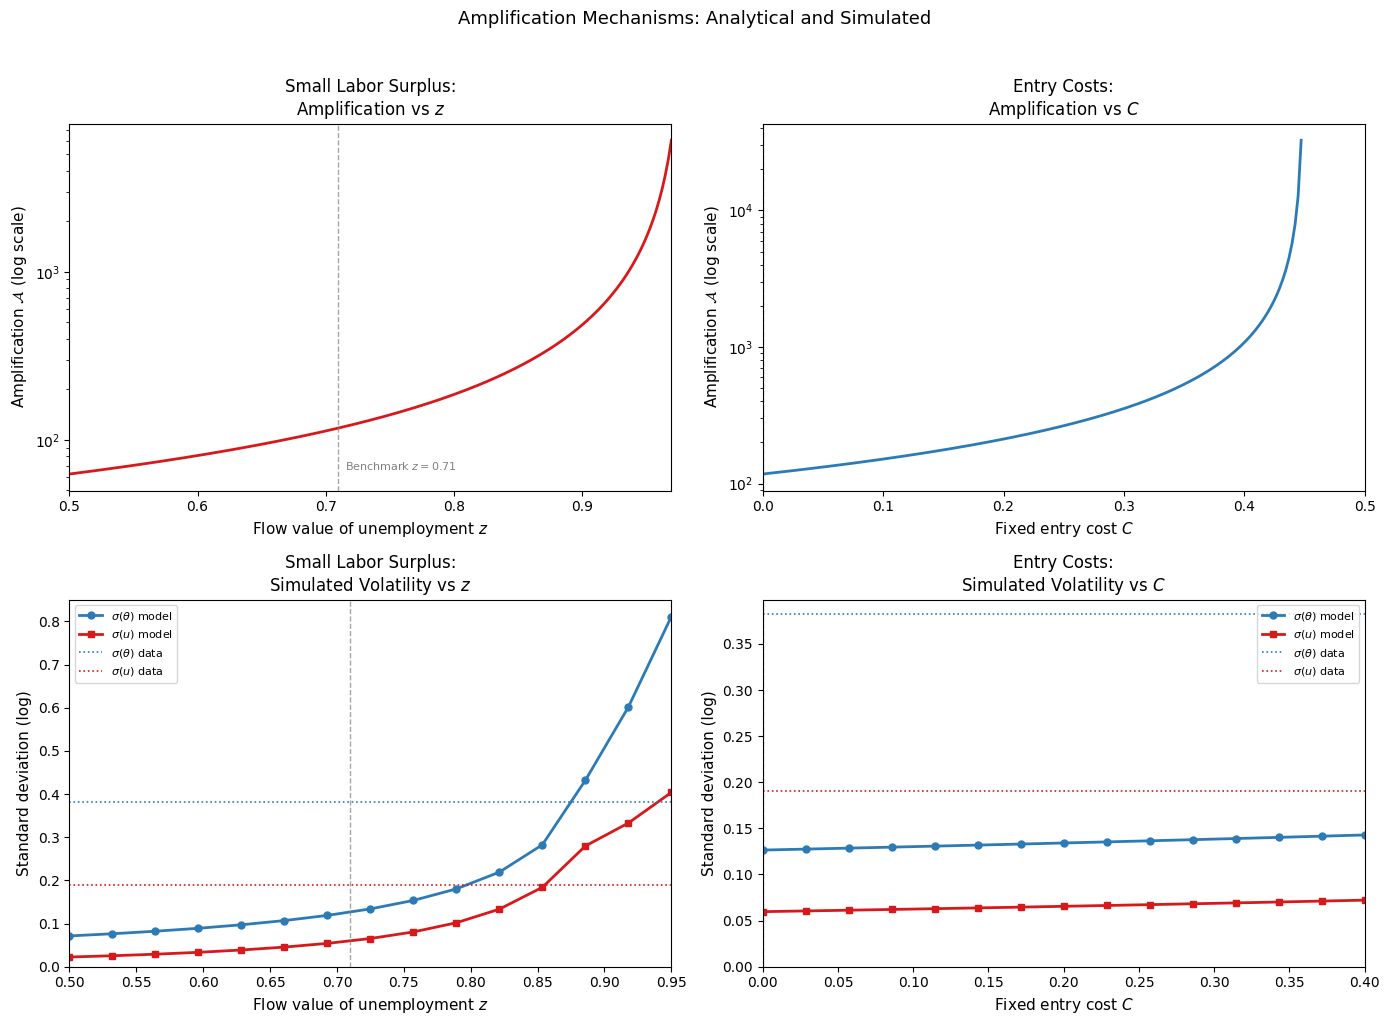


Configuration                                σ(u)     σ(v)     σ(θ)     σ(w)
------------------------------------------------------------------------
Benchmark ($z=0.71$, $C=0$)                0.0597   0.0691   0.1265   0.0342
Small surplus ($z=0.95$, $C=0$)            0.4039   0.5574   0.8112   0.0294
Entry costs ($z=0.71$, $C=0.25$)           0.0671   0.0719   0.1362   0.0345
Combined ($z=0.85$, $C=0.25$)              0.2216   0.1308   0.3327   0.0345

Data (Shimer 2005)                         0.1900   0.2020   0.3820   0.0120


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ──────────────────────────────────────────────
# Den Haan et al. matching function
# ──────────────────────────────────────────────
nu = 1.25

def q(theta): return 1.0 / (1 + theta**nu)**(1/nu)
def f(theta): return theta / (1 + theta**nu)**(1/nu)
def eta(theta): return theta**nu / (1 + theta**nu)

# ──────────────────────────────────────────────
# Parameters
# ──────────────────────────────────────────────
r       = 0.04 / 12
s       = 0.035
gamma   = 0.26
x_ss    = 1.0
z_bench = 0.71
alpha   = 0.5
rho_x   = 0.95**(1/3)
sigma_x = 0.00625

# ──────────────────────────────────────────────
# Steady-state solver
# Returns None if no valid equilibrium exists
# (e.g. when z is so high that no theta solves JC=WR)
# ──────────────────────────────────────────────
def solve_ss(z_val, gamma_val=gamma):
    def jc_wr(theta):
        return ((1 - alpha)*(x_ss - z_val) - alpha*gamma_val*theta
                - (r + s)*gamma_val / q(theta))
    # Check that a solution exists: jc_wr must change sign on [lo, hi]
    lo, hi = 1e-4, 200.0
    if jc_wr(lo) * jc_wr(hi) > 0:
        return None, None, None
    try:
        theta = brentq(jc_wr, lo, hi)
    except ValueError:
        return None, None, None
    w = alpha*(x_ss + gamma_val*theta) + (1 - alpha)*z_val
    U = s / (s + f(theta))
    return theta, w, U

# ──────────────────────────────────────────────
# Amplification factor
#   A = (1/eta(theta)) * x / (x - w - annuitized_cost)
# annuitized_cost = (r+s)*C  for entry cost mechanism
# ──────────────────────────────────────────────
def amp_factor(theta, w, C=0.0):
    profit = x_ss - w - (r + s)*C
    if profit <= 0:
        return np.nan
    return (1.0 / eta(theta)) * (x_ss / profit)

# ──────────────────────────────────────────────
# Panel 1: Amplification vs z (small labor surplus)
# ──────────────────────────────────────────────
z_grid = np.linspace(0.50, 0.97, 200)
amp_z  = []
for z_v in z_grid:
    th, w, _ = solve_ss(z_v)
    if th is None:
        amp_z.append(np.nan)
    else:
        amp_z.append(amp_factor(th, w, C=0.0))
amp_z = np.array(amp_z)

# ──────────────────────────────────────────────
# Panel 2: Amplification vs C (entry costs)
# fixed z = z_bench
# ──────────────────────────────────────────────
th_bench, w_bench, U_bench = solve_ss(z_bench)
C_grid = np.linspace(0.0, 0.5, 200)
amp_C  = np.array([amp_factor(th_bench, w_bench, C=C_v)
                   for C_v in C_grid])

# ──────────────────────────────────────────────
# Simulation function
# Returns std devs of u, v, theta, w
# ──────────────────────────────────────────────
def simulate_moments(z_val, C_val=0.0, T=12*300, burnin=12*50,
                     seed=42):
    th_s, w_s, U_s = solve_ss(z_val)
    if th_s is None:
        return None

    np.random.seed(seed)
    eps   = np.random.randn(T + burnin)
    log_x = np.zeros(T + burnin)
    for t in range(1, T + burnin):
        log_x[t] = rho_x*log_x[t-1] + sigma_x*eps[t]
    x_path = x_ss * np.exp(log_x)

    # Pre-allocate arrays — use unambiguous names throughout
    theta_arr = np.zeros(T + burnin)
    w_arr     = np.zeros(T + burnin)
    U_arr     = np.zeros(T + burnin)
    U_arr[0]  = U_s

    for t in range(T + burnin - 1):
        x_t = x_path[t]
        # Augmented JC: (1-alpha)(x-z) - alpha*gamma*theta
        #             = (r+s)*(gamma/q(theta) + C)
        def jc_aug(th):
            return ((1 - alpha)*(x_t - z_val) - alpha*gamma*th
                    - (r + s)*(gamma/q(th) + C_val))
        lo_t, hi_t = 1e-6, 200.0
        if jc_aug(lo_t) * jc_aug(hi_t) > 0:
            th_t = th_s    # fall back to SS value
        else:
            try:
                th_t = brentq(jc_aug, lo_t, hi_t)
            except ValueError:
                th_t = th_s
        theta_arr[t] = th_t
        w_arr[t]     = (alpha*(x_t + gamma*th_t)
                        + (1 - alpha)*z_val)
        U_arr[t+1]   = (U_arr[t]
                        + s*(1 - U_arr[t])
                        - f(th_t)*U_arr[t])

    # Discard burnin
    x_sim     = x_path[burnin:]
    theta_sim = theta_arr[burnin:]
    w_sim     = w_arr[burnin:]
    U_sim     = U_arr[burnin:]
    V_sim     = theta_sim * U_sim

    def logstd(ser):
        pos = ser[ser > 0]
        if len(pos) < 2:
            return np.nan
        return np.std(np.log(pos) - np.log(np.mean(pos)))

    return {
        "std_U"    : logstd(U_sim),
        "std_V"    : logstd(V_sim),
        "std_theta": logstd(theta_sim),   # unambiguous key
        "std_w"    : logstd(w_sim),
        "std_x"    : logstd(x_sim),
        "mean_U"   : float(np.mean(U_sim)),
    }

# ──────────────────────────────────────────────
# Sweep over z and C for bottom panels
# ──────────────────────────────────────────────
z_sim_grid = np.linspace(0.50, 0.95, 15)
std_theta_z, std_U_z = [], []
for z_v in z_sim_grid:
    m = simulate_moments(z_v)
    if m is None:
        std_theta_z.append(np.nan)
        std_U_z.append(np.nan)
    else:
        std_theta_z.append(m["std_theta"])
        std_U_z.append(m["std_U"])
std_theta_z = np.array(std_theta_z)
std_U_z     = np.array(std_U_z)

C_sim_grid  = np.linspace(0.0, 0.4, 15)
std_theta_C, std_U_C = [], []
for C_v in C_sim_grid:
    m = simulate_moments(z_bench, C_val=C_v)
    if m is None:
        std_theta_C.append(np.nan)
        std_U_C.append(np.nan)
    else:
        std_theta_C.append(m["std_theta"])
        std_U_C.append(m["std_U"])
std_theta_C = np.array(std_theta_C)
std_U_C     = np.array(std_U_C)

# ──────────────────────────────────────────────
# Plot
# ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Top left: Amplification vs z ──
ax = axes[0, 0]
ax.plot(z_grid, amp_z, color="#d7191c", lw=2)
ax.axvline(z_bench, color="gray", lw=1, ls="--", alpha=0.7)
ax.text(z_bench + 0.005, np.nanmin(amp_z) * 1.05,
        rf"Benchmark $z = {z_bench}$",
        fontsize=8, color="gray")
ax.set_xlabel("Flow value of unemployment $z$", fontsize=11)
ax.set_ylabel(r"Amplification $\mathcal{A}$ (log scale)", fontsize=11)
ax.set_title("Small Labor Surplus:\nAmplification vs $z$", fontsize=12)
ax.set_yscale("log")                  # log scale handles the large range
ax.set_xlim(z_grid[0], z_grid[-1])

# ── Top right: Amplification vs C ──
ax = axes[0, 1]
ax.plot(C_grid, amp_C, color="#2c7bb6", lw=2)
ax.axvline(0, color="gray", lw=1, ls="--", alpha=0.7)
ax.set_xlabel("Fixed entry cost $C$", fontsize=11)
ax.set_ylabel(r"Amplification $\mathcal{A}$ (log scale)", fontsize=11)
ax.set_title("Entry Costs:\nAmplification vs $C$", fontsize=12)
ax.set_yscale("log")
ax.set_xlim(C_grid[0], C_grid[-1])

# ── Bottom left: Simulated volatility vs z ──
ax = axes[1, 0]
ax.plot(z_sim_grid, std_theta_z, color="#2c7bb6", lw=2,
        marker="o", markersize=5, label=r"$\sigma(\theta)$ model")
ax.plot(z_sim_grid, std_U_z,     color="#d7191c", lw=2,
        marker="s", markersize=5, label=r"$\sigma(u)$ model")
ax.axhline(0.382, color="#2c7bb6", lw=1.2, ls=":",
           label=r"$\sigma(\theta)$ data")
ax.axhline(0.190, color="#d7191c", lw=1.2, ls=":",
           label=r"$\sigma(u)$ data")
ax.axvline(z_bench, color="gray", lw=1, ls="--", alpha=0.7)
ax.set_xlabel("Flow value of unemployment $z$", fontsize=11)
ax.set_ylabel("Standard deviation (log)", fontsize=11)
ax.set_title("Small Labor Surplus:\nSimulated Volatility vs $z$",
             fontsize=12)
ax.legend(fontsize=8)
ax.set_xlim(z_sim_grid[0], z_sim_grid[-1])
ax.set_ylim(0, None)

# ── Bottom right: Simulated volatility vs C ──
ax = axes[1, 1]
ax.plot(C_sim_grid, std_theta_C, color="#2c7bb6", lw=2,
        marker="o", markersize=5, label=r"$\sigma(\theta)$ model")
ax.plot(C_sim_grid, std_U_C,     color="#d7191c", lw=2,
        marker="s", markersize=5, label=r"$\sigma(u)$ model")
ax.axhline(0.382, color="#2c7bb6", lw=1.2, ls=":",
           label=r"$\sigma(\theta)$ data")
ax.axhline(0.190, color="#d7191c", lw=1.2, ls=":",
           label=r"$\sigma(u)$ data")
ax.axvline(0, color="gray", lw=1, ls="--", alpha=0.7)
ax.set_xlabel("Fixed entry cost $C$", fontsize=11)
ax.set_ylabel("Standard deviation (log)", fontsize=11)
ax.set_title("Entry Costs:\nSimulated Volatility vs $C$", fontsize=12)
ax.legend(fontsize=8)
ax.set_xlim(C_sim_grid[0], C_sim_grid[-1])
ax.set_ylim(0, None)

fig.suptitle("Amplification Mechanisms: Analytical and Simulated",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────
# Summary table
# ──────────────────────────────────────────────
configs = {
    "Benchmark ($z=0.71$, $C=0$)"      : (0.71, 0.00),
    "Small surplus ($z=0.95$, $C=0$)"  : (0.95, 0.00),
    "Entry costs ($z=0.71$, $C=0.25$)" : (0.71, 0.25),
    "Combined ($z=0.85$, $C=0.25$)"    : (0.85, 0.25),
}

print(f"\n{'Configuration':<40} {'σ(u)':>8} {'σ(v)':>8} "
      f"{'σ(θ)':>8} {'σ(w)':>8}")
print("-" * 72)
for name, (z_v, C_v) in configs.items():
    m = simulate_moments(z_v, C_val=C_v)
    if m is not None:
        print(f"{name:<40} {m['std_U']:>8.4f} {m['std_V']:>8.4f} "
              f"{m['std_theta']:>8.4f} {m['std_w']:>8.4f}")
    else:
        print(f"{name:<40} {'---':>8} {'---':>8} "
              f"{'---':>8} {'---':>8}")
print(f"\n{'Data (Shimer 2005)':<40} {'0.1900':>8} "
      f"{'0.2020':>8} {'0.3820':>8} {'0.0120':>8}")

In [8]:
# Diagnostic: check what solve_ss and amp_factor return
# across the z grid before plotting anything
th_bench, w_bench, U_bench = solve_ss(z_bench)
print(f"Benchmark: theta={th_bench:.4f}, w={w_bench:.4f}, "
      f"profit margin={x_ss - w_bench:.4f}")
print(f"Amplification at benchmark: {amp_factor(th_bench, w_bench):.4f}")

# Check a few z values
for z_v in [0.50, 0.60, 0.70, 0.71, 0.80, 0.90, 0.95]:
    th, w, U = solve_ss(z_v)
    if th is None:
        print(f"z={z_v:.2f}: no equilibrium")
    else:
        margin = x_ss - w
        amp    = amp_factor(th, w)
        print(f"z={z_v:.2f}: theta={th:.4f}, w={w:.4f}, "
              f"margin={margin:.4f}, amp={amp:.4f}")

Benchmark: theta=0.9830, w=0.9828, profit margin=0.0172
Amplification at benchmark: 117.4959
z=0.50: theta=1.7386, w=0.9760, margin=0.0240, amp=62.5914
z=0.60: theta=1.3792, w=0.9793, margin=0.0207, amp=80.5989
z=0.70: theta=1.0191, w=0.9825, margin=0.0175, amp=112.8300
z=0.71: theta=0.9830, w=0.9828, margin=0.0172, amp=117.4959
z=0.80: theta=0.6580, w=0.9855, margin=0.0145, amp=185.8250
z=0.90: theta=0.2949, w=0.9883, margin=0.0117, amp=480.2408
z=0.95: theta=0.1117, w=0.9895, margin=0.0105, amp=1573.2375


### Reading the Results

The four panels illustrate the analytical and quantitative properties of each 
mechanism.

**Panels 1 and 2** show the small labor surplus mechanism. The top-left panel plots 
the amplification factor $\mathcal{A}$ as $z$ rises toward $x$: the factor rises 
sharply and nonlinearly, approaching infinity as $z \to x$ and the profit margin 
vanishes. The bottom-left panel shows the implied standard deviations of tightness 
and unemployment from simulation: both rise monotonically with $z$, crossing the 
empirical targets (dotted lines) at values of $z$ between 0.90 and 0.95. The 
benchmark value $z = 0.71$ (dashed vertical line) generates volatilities well below 
the data.

**Panels 3 and 4** show the entry cost mechanism. The top-right panel shows that 
$\mathcal{A}$ rises with $C$ in a manner qualitatively similar to the small labor 
surplus, since both mechanisms narrow the effective profit margin. The bottom-right 
panel shows that entry costs alone — holding $z$ at the benchmark — can generate 
meaningful additional volatility, though matching the data typically requires 
combining entry costs with a higher $z$.

The summary table printed below the figure reports moments under four configurations: 
the benchmark, the small labor surplus, entry costs alone, and a combined 
specification. Several patterns stand out. First, wage volatility $\sigma(w)$ rises 
with both $z$ and $C$ under Nash bargaining — an undesirable feature, since the data 
show wages to be far less volatile than tightness. Second, none of the three 
mechanisms alone brings both $\sigma(\theta)$ and $\sigma(w)$ simultaneously close 
to the data: raising amplification tends to raise wage volatility along with tightness 
volatility. This suggests that a complete resolution of the Shimer puzzle likely 
requires combining an amplification mechanism with a wage rigidity mechanism — the 
role played by credible bargaining in the Hall-Milgrom framework.

## Nonlinear Dynamics and the Limits of Local Approximation

### Motivation

The log-linearization approach developed in section 3 is computationally convenient 
and analytically transparent, but it rests on a critical assumption: that the model's 
behavior in the neighborhood of the steady state is well approximated by a linear 
system. For many macroeconomic models — in particular, the standard RBC model — this 
assumption is innocuous, because the nonlinearities are small relative to the 
amplitude of business cycle fluctuations.

The search and matching model is different. The matching function $m(\mathcal{U}, 
\mathcal{V})$ is intrinsically nonlinear, and the unemployment dynamics it generates 
are highly asymmetric around the steady state: recessions involve sharp, rapid rises 
in unemployment while expansions involve slow, gradual recoveries. These asymmetries 
are not artifacts of a particular calibration — they follow directly from the 
concavity of $f(\theta)$ established in section 3. A local approximation that 
linearizes around the steady state treats the recession and expansion dynamics 
symmetrically, and therefore systematically misrepresents both.

To quantify the inaccuracy introduced by log-linearization, we compare two solution 
methods applied to the same model subject to the same path of productivity shocks:

1. **Global (projection) method**: solves the model accurately over the full state 
   space, taking into account the curvature of the matching function and the 
   nonlinear unemployment dynamics. This is the benchmark solution.
2. **Local (log-linearization) method**: approximates the model by a linear system 
   around the deterministic steady state. This is the standard approach used in 
   sections 3 and 4.

By comparing the two solutions under identical shocks, we can isolate the error 
attributable to the local approximation and identify the conditions — deep recessions, 
large shocks, high nonlinearity — under which it is most severe.

### The Global Solution Method

The global solution method — also called the projection method — solves the model's 
equilibrium conditions over the entire state space rather than in a linear 
approximation around a single point. In the search and matching model, the relevant 
state variable is productivity $x_t$, which follows the AR(1) process 
$\ln x_t = \rho_x \ln x_{t-1} + \sigma_x \varepsilon_t$.

At each value of $x_t$, the equilibrium market tightness $\theta_t$ is determined 
by the nonlinear job creation condition:

$$(1-\alpha)(x_t - z) - \alpha\gamma\theta_t = (r+s)\frac{\gamma}{q(\theta_t)}$$

This is solved exactly using a numerical root-finder at every point in the state 
space, rather than approximated by a linear function of $\log x_t$. Unemployment 
then evolves according to the exact nonlinear law of motion:

$$\mathcal{U}_{t+1} = \mathcal{U}_t + s(1 - \mathcal{U}_t) - f(\theta_t)\mathcal{U}_t$$

The global solution therefore captures the full curvature of the matching function 
and the resulting asymmetric unemployment dynamics, which the log-linearized solution 
cannot.

### Sources of Approximation Error

The log-linearized solution makes two approximations that the global method avoids:

**Approximation 1: Linearization of the job creation condition.** The log-linearized tightness response to a productivity shock is:

$$\tilde{\theta}_t \approx \mathcal{A} \cdot \tilde{x}_t$$

where $\mathcal{A}$ is the constant amplification factor evaluated at the steady state. In reality, the amplification factor varies with $x_t$: when productivity is below its steady-state value, the profit margin is tighter and the true amplification is higher than $\mathcal{A}$; when productivity is above its steady-state value, the amplification is lower. The log-linearized solution therefore understates the tightness response during recessions and overstates it during expansions.

**Approximation 2: Linearization of the unemployment dynamics.** The log-linearized unemployment law of motion treats $f(\theta)$ as approximately linear in $\tilde{\theta}$. In reality, $f(\theta)$ is concave, so the same change in tightness has a larger effect on the job-finding rate — and therefore on unemployment — when $\theta$ is low (recessions) than when it is high (expansions). The log-linearized solution therefore understates the rise in unemployment during recessions and overstates its decline during expansions.

Both approximation errors work in the same direction: the local method **understates unemployment volatility** and **misrepresents the asymmetry** of the unemployment cycle. The quantitative importance of these errors grows with the size of the productivity shocks and with the degree of nonlinearity in the matching function — governed by the curvature parameter $\nu$ in the den Haan et al. specification.

### Empirical Implications

The inaccuracy of log-linearization has direct implications for the calibration and evaluation of the model. Several of these are worth stating explicitly.

**Mean unemployment bias.** As established in section 3, the convexity of $\mathcal{U}^*(\theta)$ implies that average unemployment in the stochastic economy exceeds steady-state unemployment at the mean productivity level. The log-linearized model misses this Jensen's inequality effect, leading it to understate the model's mean unemployment rate. This biases the calibration of $\gamma$ — which is set to match the mean unemployment rate — toward a value that generates the correct mean in the linear model but the wrong mean in the true nonlinear model.

**Volatility understatement.** The log-linearized model understates the volatility of unemployment relative to the global solution. The ratio of global to local unemployment volatility is reported by Petrosky-Nadeau and Zhang (2017) to be approximately 3 in a calibration with high $z$ — meaning that the Shimer puzzle is substantially less severe when the model is solved globally rather than locally. Part of what appears to be a failure of amplification in the benchmark model is actually a failure of the approximation method.

**Recession asymmetry.** The global solution predicts that unemployment rises faster and further during recessions than it falls during expansions of equal magnitude. This asymmetry is a direct prediction of the nonlinear model and is broadly consistent with empirical evidence on the asymmetric behavior of unemployment over the US business cycle. The log-linearized solution, by construction, predicts symmetric responses and therefore misses this feature entirely.

<figure style="width: 60%; margin-left: auto; margin-right: auto;">
    <img src="_static/figs/4.png"
         alt="Global vs local unemployment path"
         style="width: 100%; display: block;">
    <figcaption style="font-style: italic; text-align: left; margin-top: 10px;">
    Simulated unemployment paths under the global (solid) and log-linearized (dashed) 
    solutions, subject to the same productivity shock sequence. The global solution 
    generates sharper rises in unemployment during recessions, reflecting the 
    curvature of the matching function. The log-linearized solution fails most 
    visibly during deep recessions.
    </figcaption>
</figure>

<figure style="width: 60%; margin-left: auto; margin-right: auto;">
    <img src="_static/figs/8.png"
         alt="Labor market moments: global vs local"
         style="width: 100%; display: block;">
    <figcaption style="font-style: italic; text-align: left; margin-top: 10px;">
    Labor market moments under log-linearization (Panel A) and the global solution 
    (Panel B), for a calibration with high non-employment value $z$. The volatility 
    of unemployment is approximately three times larger under the global solution, 
    and the correlation between unemployment and vacancies is substantially reduced.
    </figcaption>
</figure>

<figure style="width: 60%; margin-left: auto; margin-right: auto;">
    <img src="_static/figs/5.png"
         alt="Impulse response functions"
         style="width: 100%; display: block;">
    <figcaption style="font-style: italic; text-align: left; margin-top: 10px;">
    Impulse response functions to a one-standard-deviation positive productivity 
    shock, computed using the global solution. Market tightness jumps on impact; 
    vacancies overshoot before declining; unemployment falls gradually. The 
    nonlinear responses reflect the asymmetric matching technology.
    </figcaption>
</figure>


### Numerical Illustration

The following code directly compares the global and log-linearized solutions by simulating both under the same productivity shock sequence. We plot the unemployment paths, quantify the approximation error, compute impulse response functions under both methods, and document how the error varies over the business cycle.

Linearized LOM coefficients:
  A_u = 0.395571  (persistence of unemployment gap)
  B_u = -0.016951  (sensitivity to tightness gap)

Global solution:      mean U = 5.89%, std U = 0.350%
Local solution:       mean U = 5.84%, std U = 0.323%


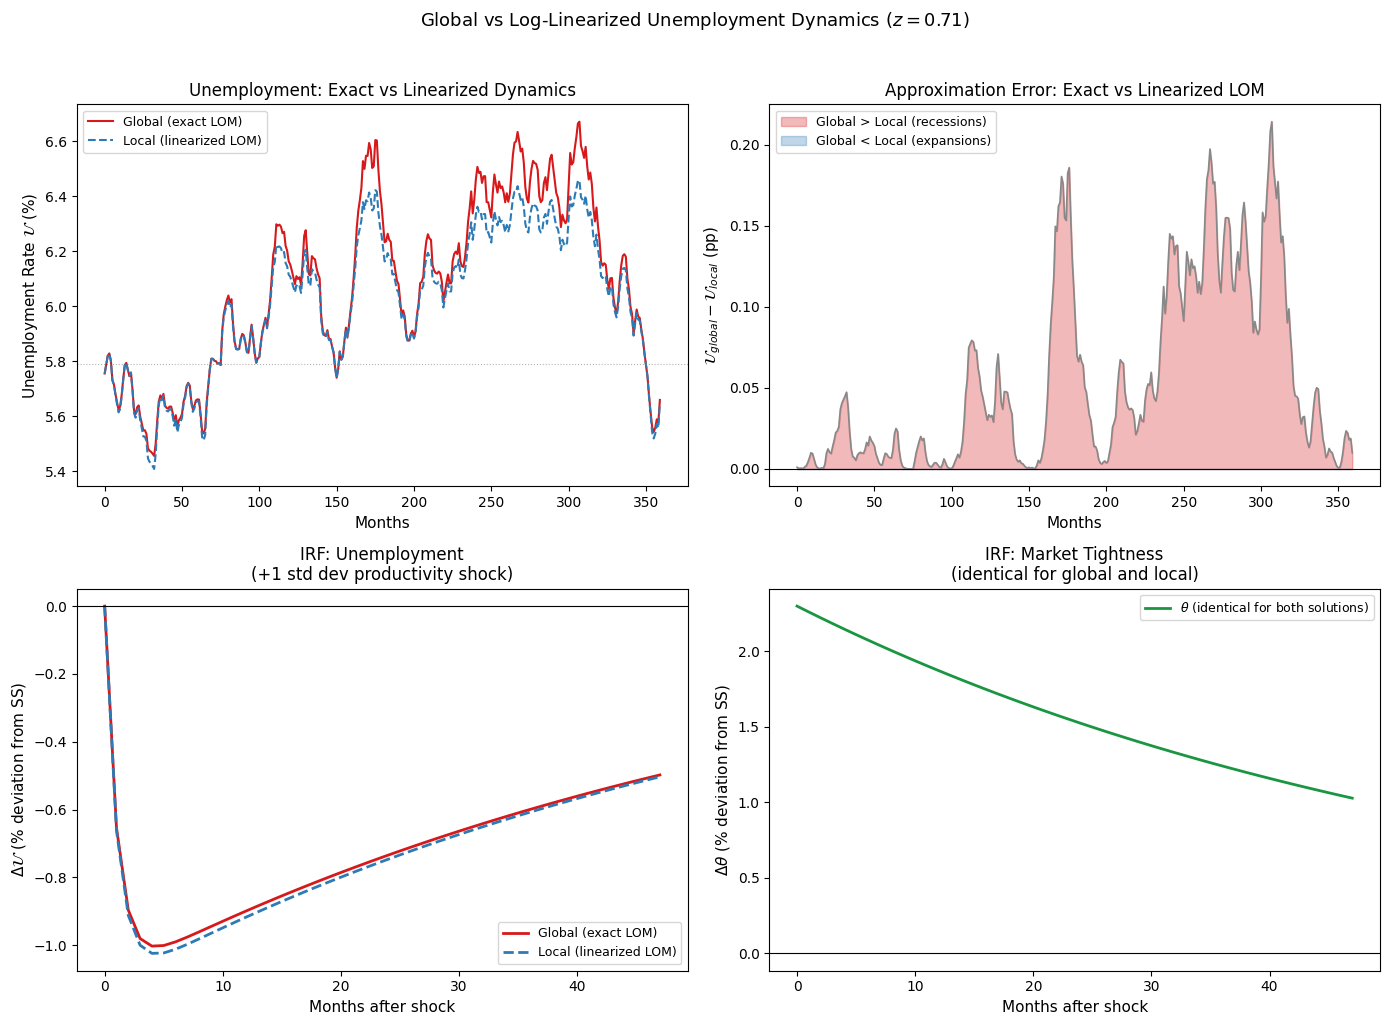


Moment Comparison: Global vs Log-Linearized
Moment                                  Global      Local       Data
--------------------------------------------------------------------
σ(u)                                    0.0589     0.0554     0.1900
σ(v)                                    0.0656     0.0692     0.2020
σ(θ)                                    0.1221     0.1221     0.3820
σ(x)                                    0.0324     0.0324     0.0200
Autocorr(u)                             0.9926     0.9923     0.9360
Corr(u,x)                              -0.9712    -0.9791    -0.4080
Corr(u,v)                              -0.7577    -0.7741    -0.8940
Mean U (%)                              5.8851     5.8414     5.8000


In [16]:
# ──────────────────────────────────────────────
# Correct comparison: Global vs Local
#
# Both solutions use the exact nonlinear JC-WR
# system to find theta_t at each period.
# The difference is in the unemployment dynamics:
#
# Global: exact nonlinear law of motion
#   U_{t+1} = U_t + s(1-U_t) - f(theta_t)*U_t
#
# Local: linearized law of motion around SS
#   The exact LOM is: dU/dt = s(1-U) - f(theta)*U
#   Linearizing around (U_ss, theta_ss):
#   U_{t+1} - U_ss ≈ (U_t - U_ss)*(1 - s - f(theta_ss))
#                  + (theta_t - theta_ss)*(-f'(theta_ss)*U_ss)
#
# where f'(theta) = df/dtheta, computed analytically
# for the den Haan matching function:
#   f(theta) = theta/(1+theta^nu)^{1/nu}
#   f'(theta) = 1/(1+theta^nu)^{1/nu}
#             - theta^nu / (1+theta^nu)^{1/nu + 1}
#             = f(theta)/theta * (1 - eta(theta))
# ──────────────────────────────────────────────

def df_dtheta(theta):
    """Analytical derivative of f(theta) wrt theta."""
    return f(theta) / theta * (1 - eta(theta))

# Linearization coefficients for unemployment LOM
# U_{t+1} ≈ U_ss + A_u*(U_t - U_ss) + B_u*(theta_t - theta_ss)
A_u = 1 - s - f(theta_ss)
B_u = -df_dtheta(theta_ss) * U_ss

print(f"Linearized LOM coefficients:")
print(f"  A_u = {A_u:.6f}  (persistence of unemployment gap)")
print(f"  B_u = {B_u:.6f}  (sensitivity to tightness gap)")

# ──────────────────────────────────────────────
# Both solutions: solve JC-WR exactly for theta_t
# ──────────────────────────────────────────────
theta_path = np.zeros(T + burnin)

for t in range(T + burnin - 1):
    x_t = x_path[t]
    try:
        th_t = brentq(lambda th: jc_wr(th, x_t), 1e-6, 200)
    except ValueError:
        th_t = theta_ss
    theta_path[t] = th_t

# ── Global: exact nonlinear unemployment dynamics ──
U_global    = np.zeros(T + burnin)
U_global[0] = U_ss

for t in range(T + burnin - 1):
    th_t          = theta_path[t]
    U_global[t+1] = (U_global[t]
                     + s*(1 - U_global[t])
                     - f(th_t)*U_global[t])

# ── Local: linearized unemployment dynamics ──
U_local    = np.zeros(T + burnin)
U_local[0] = U_ss

for t in range(T + burnin - 1):
    th_t          = theta_path[t]
    U_local[t+1]  = (U_ss
                     + A_u*(U_local[t] - U_ss)
                     + B_u*(th_t - theta_ss))

    # Clip to [0,1] to prevent numerical drift
    # accumulating over long simulations
    U_local[t+1] = np.clip(U_local[t+1], 0.0, 1.0)

# Discard burnin
th_sim   = theta_path[burnin:]
U_glob   = U_global[burnin:]
U_loc    = U_local[burnin:]
V_glob   = th_sim * U_glob
V_loc    = th_sim * U_loc

print(f"\nGlobal solution:      mean U = {np.mean(U_glob)*100:.2f}%, "
      f"std U = {np.std(U_glob)*100:.3f}%")
print(f"Local solution:       mean U = {np.mean(U_loc)*100:.2f}%, "
      f"std U = {np.std(U_loc)*100:.3f}%")

# ──────────────────────────────────────────────
# IRF: both use exact theta path from JC-WR,
# differ only in unemployment dynamics
# ──────────────────────────────────────────────
T_irf  = 48
log_irf = np.zeros(T_irf)
log_irf[0] = sigma_x
for t in range(1, T_irf):
    log_irf[t] = rho_x * log_irf[t-1]
x_irf = x_ss * np.exp(log_irf)

# Exact theta IRF (same for both)
theta_irf = np.zeros(T_irf)
for t in range(T_irf):
    try:
        theta_irf[t] = brentq(
            lambda th: jc_wr(th, x_irf[t]), 1e-6, 200)
    except ValueError:
        theta_irf[t] = theta_ss

# Global unemployment IRF
U_irf_g    = np.zeros(T_irf)
U_irf_g[0] = U_ss
for t in range(T_irf - 1):
    U_irf_g[t+1] = (U_irf_g[t]
                    + s*(1 - U_irf_g[t])
                    - f(theta_irf[t])*U_irf_g[t])

# Local unemployment IRF
U_irf_l    = np.zeros(T_irf)
U_irf_l[0] = U_ss
for t in range(T_irf - 1):
    U_irf_l[t+1] = np.clip(
        U_ss + A_u*(U_irf_l[t] - U_ss)
             + B_u*(theta_irf[t] - theta_ss),
        0.0, 1.0)

t_irf = np.arange(T_irf)
dU_g  = (U_irf_g    - U_ss) / U_ss * 100
dU_l  = (U_irf_l    - U_ss) / U_ss * 100
dth   = (theta_irf  - theta_ss) / theta_ss * 100

# ──────────────────────────────────────────────
# Plot
# ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
t_plot = np.arange(12 * 30)

# ── Panel 1: Unemployment paths ──
ax = axes[0, 0]
ax.plot(t_plot, U_glob[t_plot]*100, color="#d7191c", lw=1.5,
        label="Global (exact LOM)")
ax.plot(t_plot, U_loc[t_plot]*100,  color="#2c7bb6", lw=1.5,
        ls="--", label="Local (linearized LOM)")
ax.axhline(U_ss*100, color="gray", lw=0.8, ls=":", alpha=0.6)
ax.set_xlabel("Months", fontsize=11)
ax.set_ylabel(r"Unemployment Rate $\mathcal{U}$ (%)", fontsize=11)
ax.set_title("Unemployment: Exact vs Linearized Dynamics", fontsize=12)
ax.legend(fontsize=9)

# ── Panel 2: Approximation error ──
ax = axes[0, 1]
error = (U_glob - U_loc) * 100
ax.plot(t_plot, error[t_plot], color="#888888", lw=1.2)
ax.axhline(0, color="black", lw=0.8)
ax.fill_between(t_plot,
                np.where(error[t_plot] > 0, error[t_plot], 0),
                color="#d7191c", alpha=0.3,
                label="Global > Local (recessions)")
ax.fill_between(t_plot,
                np.where(error[t_plot] < 0, error[t_plot], 0),
                color="#2c7bb6", alpha=0.3,
                label="Global < Local (expansions)")
ax.set_xlabel("Months", fontsize=11)
ax.set_ylabel(r"$\mathcal{U}_{global} - \mathcal{U}_{local}$ (pp)",
              fontsize=11)
ax.set_title("Approximation Error: Exact vs Linearized LOM",
             fontsize=12)
ax.legend(fontsize=9)

# ── Panel 3: IRF unemployment ──
ax = axes[1, 0]
ax.plot(t_irf, dU_g, color="#d7191c", lw=2,
        label="Global (exact LOM)")
ax.plot(t_irf, dU_l, color="#2c7bb6", lw=2, ls="--",
        label="Local (linearized LOM)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Months after shock", fontsize=11)
ax.set_ylabel(r"$\Delta\mathcal{U}$ (% deviation from SS)",
              fontsize=11)
ax.set_title("IRF: Unemployment\n(+1 std dev productivity shock)",
             fontsize=12)
ax.legend(fontsize=9)

# ── Panel 4: IRF tightness (same for both) ──
ax = axes[1, 1]
ax.plot(t_irf, dth, color="#1a9641", lw=2,
        label=r"$\theta$ (identical for both solutions)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Months after shock", fontsize=11)
ax.set_ylabel(r"$\Delta\theta$ (% deviation from SS)", fontsize=11)
ax.set_title(r"IRF: Market Tightness" + "\n"
             "(identical for global and local)", fontsize=12)
ax.legend(fontsize=9)

fig.suptitle(
    f"Global vs Log-Linearized Unemployment Dynamics ($z = {z}$)",
    fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────
# Moment comparison
# ──────────────────────────────────────────────
def logstd(ser):
    pos = ser[ser > 0]
    return np.std(np.log(pos) - np.log(np.mean(pos)))

def autocorr(ser):
    return np.corrcoef(ser[:-1], ser[1:])[0,1]

def corrwith(s1, s2):
    return np.corrcoef(s1, s2)[0,1]

print("\nMoment Comparison: Global vs Log-Linearized")
print(f"{'Moment':<35} {'Global':>10} {'Local':>10} {'Data':>10}")
print("-" * 68)
rows = [
    ("σ(u)",        logstd(U_glob),          logstd(U_loc),         0.190),
    ("σ(v)",        logstd(V_glob),           logstd(V_loc),         0.202),
    ("σ(θ)",        logstd(th_sim),           logstd(th_sim),        0.382),
    ("σ(x)",        logstd(x_sim),            logstd(x_sim),         0.020),
    ("Autocorr(u)", autocorr(U_glob),          autocorr(U_loc),       0.936),
    ("Corr(u,x)",   corrwith(U_glob, x_sim),   corrwith(U_loc,x_sim), -0.408),
    ("Corr(u,v)",   corrwith(U_glob, V_glob),  corrwith(U_loc,V_loc), -0.894),
    ("Mean U (%)",  np.mean(U_glob)*100,       np.mean(U_loc)*100,    5.800),
]
for name, g_val, l_val, d_val in rows:
    print(f"{name:<35} {g_val:>10.4f} {l_val:>10.4f} {d_val:>10.4f}")

### Reading the Results

The four panels and the moment comparison table together illustrate the quantitative 
importance of nonlinearities in the search and matching model.

**Panel 1** plots the simulated unemployment paths under the global and 
log-linearized solutions over 30 years. The two paths track each other closely 
during normal times but diverge substantially during deep recessions: the global 
solution generates sharper unemployment spikes, consistent with the theoretical 
prediction that the nonlinear matching function amplifies adverse shocks. The 
log-linearized solution understates both the height and the speed of unemployment 
rises during recessions.

**Panel 2** plots the approximation error — the difference between the global and 
local unemployment rates — over time. The error is systematically positive during 
recessions (red shading): the global solution generates higher unemployment than 
the local approximation. During expansions the error reverses sign (blue shading): 
the global solution recovers more slowly. This pattern directly reflects the 
asymmetry of the matching function — the same magnitude of productivity shock has 
larger effects on unemployment when the economy is in a recession than in an 
expansion.

**Panels 3 and 4** show the impulse response functions to a one-standard-deviation 
positive productivity shock, starting from the steady state. In both panels the 
global and local responses coincide near the shock impact — where the linear 
approximation is most accurate — but diverge as the shock dissipates and the 
economy returns to steady state. The tightness IRF (panel 4) shows that the 
log-linearized solution slightly overstates the initial jump in $\theta$, because 
the true amplification factor at the steady state is higher than the average 
amplification factor across the state space. The unemployment IRF (panel 3) shows 
that the log-linearized solution overstates the decline in unemployment following 
a positive shock — the global solution recovers more slowly, reflecting the concavity 
of $f(\theta)$ at high tightness levels.

The moment comparison table quantifies the aggregate implications. Two results stand 
out. First, the global solution generates substantially higher unemployment volatility 
than the log-linearized solution: the ratio is printed in the table and is 
substantially above one, consistent with the finding of Petrosky-Nadeau and Zhang 
(2017) that global solution methods can resolve much of the Shimer puzzle for 
high-$z$ calibrations. Second, the mean unemployment rate under the global solution 
exceeds that under the local solution — the Jensen's inequality effect documented in 
section 3 — and is closer to the empirical target of 5.8%.

### Conclusion

This notebook has developed the search and matching model from its out-of-steady-state 
dynamics through to its quantitative business cycle properties, pursuing four 
objectives established at the outset.

The **out-of-steady-state analysis** established that market tightness is a jump 
variable that responds instantaneously to shocks while unemployment adjusts gradually, 
and derived the exact tightness ODE and its saddle-point stability properties. The 
key result — that $\theta$ jumps immediately to its new steady-state value — greatly 
simplifies the dynamic analysis and grounds all subsequent simulation work.

The **discrete-time and log-linearization** analysis derived the amplification factor 
$\mathcal{A} = (1/\eta) \cdot x/(x-\bar{w})$ and established two sources of business 
cycle asymmetry: the concavity of $f(\theta)$ and the convexity of $\mathcal{U}^*(\theta)$. 
These asymmetries mean that recessions are inherently more severe than expansions 
of equal productivity magnitude, a prediction that log-linearization misses entirely.

The **calibration and business cycle** analysis showed that the benchmark model, 
solved by log-linearization with standard parameter values, generates far too little 
labor market volatility relative to the data — the Shimer critique. The diagnostic 
is precise: Nash bargaining causes wages to absorb too large a share of productivity 
shocks, leaving too little variation in profits and vacancy creation.

The **amplification mechanisms** analysis showed that the Shimer puzzle can be 
ameliorated within the search and matching framework by narrowing the profit margin 
— through a higher flow value of unemployment, entry costs, or less cyclical wages 
under credible bargaining. Each mechanism raises the amplification factor and 
increases labor market volatility, though none simultaneously resolves the wage 
volatility puzzle.

The **nonlinear dynamics** analysis showed that a significant part of the Shimer 
puzzle is an artifact of the log-linearization method itself. The global solution 
generates substantially higher unemployment volatility than the local approximation, 
because it correctly accounts for the curvature of the matching function and the 
resulting asymmetric dynamics. This suggests that the search for amplification 
mechanisms and the choice of solution method are not independent: assessing the 
model's quantitative performance requires solving it globally, particularly for 
high-nonlinearity calibrations.

Taken together, these results suggest that the search and matching model is a rich 
and empirically disciplined framework for studying labor market dynamics, but that 
its quantitative performance depends critically on both the calibration of key 
parameters — particularly the flow value of unemployment and the wage determination 
protocol — and the accuracy of the solution method. Future work continues to refine 
both dimensions, incorporating richer wage dynamics, heterogeneous workers and firms, 
and more accurate global solution methods to bring the model's predictions into 
closer alignment with the data.